In [12]:
"""
check_nmr_stats.py
Простой скрипт для просмотра статистики NMR-ансамблей
"""

import torch
from collections import defaultdict
from pathlib import Path

# ====================== КОНФИГУРАЦИЯ ======================
REGISTRY_PATH = "/home/domain/data/aristowi/mlp_dataset_laproteina/latents/registry_with_full_coords.pt"   # ← поменяй путь, если нужно

# ====================== ОСНОВНОЙ КОД ======================
def print_nmr_statistics():
    print("Загружаем registry.pt...")
    registry = torch.load(REGISTRY_PATH, map_location="cpu")
    
    # Фильтруем только NMR записи
    nmr_entries = {k: v for k, v in registry.items() if v.get("experiment_type") == "NMR"}
    
    # Группируем по базовому PDB ID (убираем _model_XXX)
    by_base = defaultdict(list)
    for full_id in nmr_entries.keys():
        base = full_id.split('_model')[0]
        by_base[base].append(full_id)
    
    total_original_files = len(by_base)                    # сколько оригинальных NMR .pdb файлов было
    total_models = len(nmr_entries)                        # сколько всего моделей после разбиения
    
    print("\n" + "="*70)
    print("NMR АНСАМБЛИ — СТАТИСТИКА")
    print("="*70)
    print(f"Оригинальных NMR PDB файлов скачано:          {total_original_files:6d}")
    print(f"Моделей после разбиения на отдельные файлы:    {total_models:6d}")
    print(f"Среднее кол-во моделей на один ансамбль:       {total_models / total_original_files:.2f}")
    print(f"Максимальное кол-во моделей в одном ансамбле:  {max((len(m) for m in by_base.values()), default=0)}")
    print(f"Минимальное кол-во моделей в одном ансамбле:   {min((len(m) for m in by_base.values()), default=0)}")
    print(f"Ансамблей с ≥2 моделями (полезны для пар):     {sum(1 for m in by_base.values() if len(m) >= 2)}")
    print("="*70)
    
    # Топ-10 самых больших ансамблей
    print("\nТоп-10 NMR ансамблей с наибольшим количеством моделей:")
    top10 = sorted(by_base.items(), key=lambda x: len(x[1]), reverse=True)[:10]
    for base, models_list in top10:
        print(f"  {base:8s}  →  {len(models_list):3d} моделей")
    
    # Распределение по количеству моделей
    from collections import Counter
    model_counts = Counter(len(models) for models in by_base.values())
    print("\nРаспределение ансамблей по количеству моделей:")
    for num_models in sorted(model_counts.keys()):
        print(f"  {num_models:2d} моделей  →  {model_counts[num_models]:4d} ансамблей")

if __name__ == "__main__":
    print_nmr_statistics()

Загружаем registry.pt...

NMR АНСАМБЛИ — СТАТИСТИКА
Оригинальных NMR PDB файлов скачано:            6809
Моделей после разбиения на отдельные файлы:    134882
Среднее кол-во моделей на один ансамбль:       19.81
Максимальное кол-во моделей в одном ансамбле:  640
Минимальное кол-во моделей в одном ансамбле:   2
Ансамблей с ≥2 моделями (полезны для пар):     6809

Топ-10 NMR ансамблей с наибольшим количеством моделей:
  2KOX      →  640 моделей
  2LJ5      →  301 моделей
  6V5D      →  176 моделей
  2K0E      →  160 моделей
  2NR2      →  144 моделей
  1XQQ      →  128 моделей
  2K39      →  116 моделей
  2JU4      →  100 моделей
  2M8N      →  100 моделей
  2M8P      →  100 моделей

Распределение ансамблей по количеству моделей:
   2 моделей  →     8 ансамблей
   3 моделей  →     7 ансамблей
   4 моделей  →    20 ансамблей
   5 моделей  →    26 ансамблей
   6 моделей  →     7 ансамблей
   7 моделей  →    10 ансамблей
   8 моделей  →    13 ансамблей
   9 моделей  →    13 ансамблей
  10 м

✅ Загружено 7413 значений. Mean: 5.423, Median: 4.554


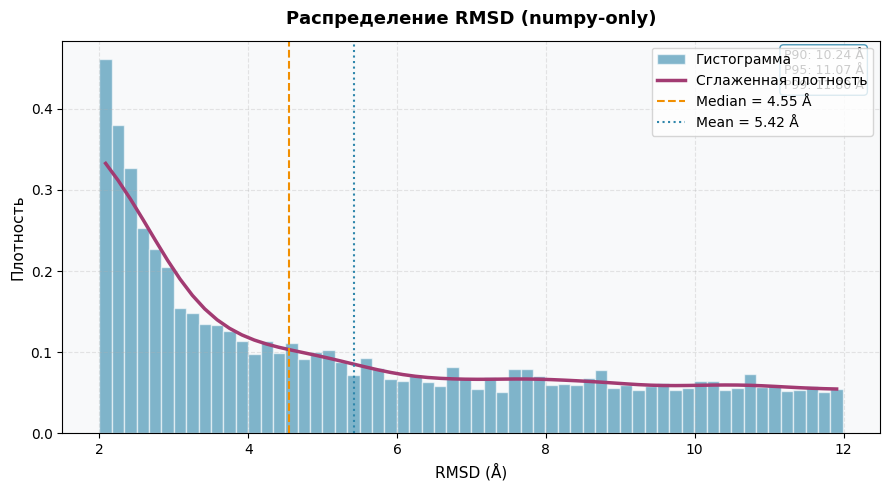

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ⚙️ Настройки
DATASET_PATH = "train_pairs_clean.pt"
RMSD_KEY     = "rmsd"

# 📦 Загрузка
data = torch.load(DATASET_PATH, map_location="cpu")
if RMSD_KEY in data:
    rmsd = data[RMSD_KEY]
elif "pairs" in data:
    rmsd = [p.get(RMSD_KEY, p.get("rmsd")) for p in data["pairs"]]
    rmsd = [r for r in rmsd if r is not None]
else:
    rmsd = data

if isinstance(rmsd, torch.Tensor): rmsd = rmsd.numpy()
rmsd = np.array(rmsd, dtype=float)
rmsd = rmsd[np.isfinite(rmsd) & (rmsd >= 0)]
print(f"✅ Загружено {len(rmsd)} значений. Mean: {rmsd.mean():.3f}, Median: {np.median(rmsd):.3f}")

# 🎨 Рисуем (чистый matplotlib + numpy)
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_facecolor("#F8F9FA")

# 1. Гистограмма
counts, bins, _ = ax.hist(rmsd, bins=60, density=True, alpha=0.6, 
                          color="#2E86AB", edgecolor="white", label="Гистограмма")

# 2. Ручное сглаживание (замена KDE без scipy)
bin_centers = (bins[:-1] + bins[1:]) / 2
sigma = (bins[1] - bins[0]) * 3  # ширина окна сглаживания
smooth_density = np.zeros_like(bin_centers)
for i, x in enumerate(bin_centers):
    weights = np.exp(-0.5 * ((bin_centers - x) / sigma) ** 2)
    weights /= weights.sum()
    smooth_density[i] = np.sum(counts * weights)

ax.plot(bin_centers, smooth_density, color="#A23B72", linewidth=2.5, label="Сглаженная плотность")

# 3. Статистика
med, mean = np.median(rmsd), np.mean(rmsd)
ax.axvline(med, color="#F18F01", ls="--", lw=1.5, label=f"Median = {med:.2f} Å")
ax.axvline(mean, color="#2E86AB", ls=":", lw=1.5, label=f"Mean = {mean:.2f} Å")

# 4. Процентили
p90, p95, p99 = np.percentile(rmsd, [90, 95, 99])
text = f"P90: {p90:.2f} Å\nP95: {p95:.2f} Å\nP99: {p99:.2f} Å"
props = dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='#2E86AB')
ax.text(0.98, 0.98, text, transform=ax.transAxes, va='top', ha='right', bbox=props, fontsize=9)

# Оформление
ax.set_xlabel("RMSD (Å)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Распределение RMSD (numpy-only)", fontsize=13, pad=12, fontweight="bold")
ax.legend(frameon=True, loc="upper right")
ax.grid(True, ls="--", alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("rmsd_distribution_numpy_only.png", dpi=300, bbox_inches="tight")
plt.show()

Структура registry:
Ключ: 107l
Тип значения: <class 'dict'>
Ключи в записи: dict_keys(['z', 'coords', 'n', 'pdb_id', 'sequence', 'experiment_type'])
Уникальных белков: 5306
Белков с найденной длиной: 5306
📊 Мода (наиболее частая длина): 64 остатков (встречается 123 раз)
✅ График сохранён: protein_length_distribution.png


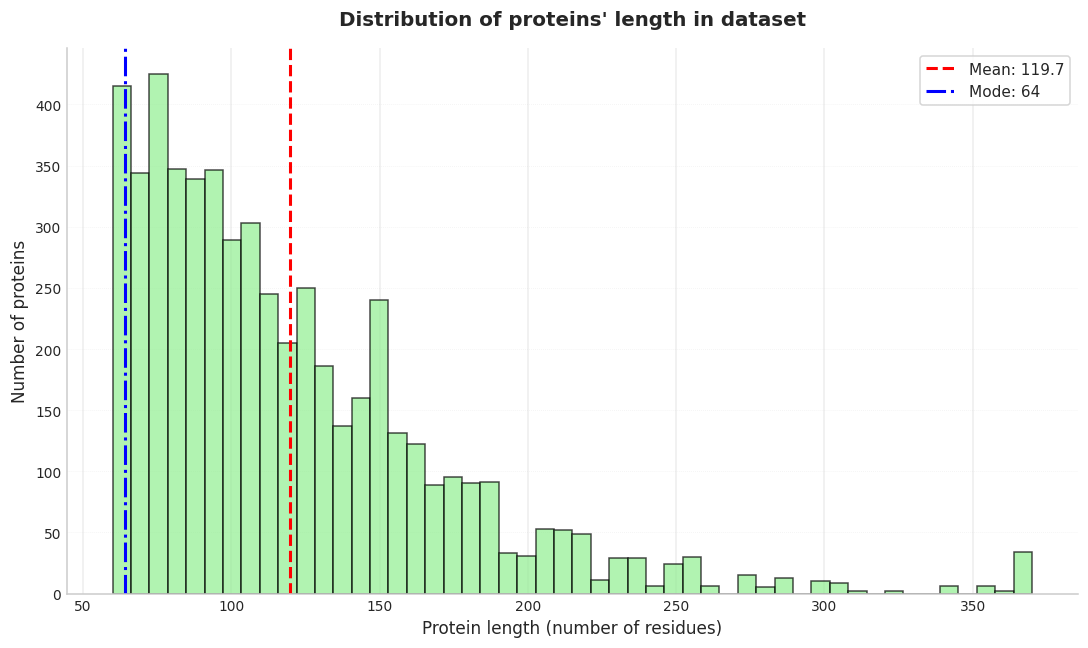

In [33]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Загрузка
train_pairs = torch.load("train_pairs_clean.pt", map_location="cpu")
registry = torch.load("/home/domain/data/aristowi/mlp_dataset_laproteina/latents/registry_with_full_coords.pt", map_location="cpu")

# Проверка структуры первого элемента registry
print("Структура registry:")
first_key = list(registry.keys())[0]
print(f"Ключ: {first_key}")
print(f"Тип значения: {type(registry[first_key])}")

if isinstance(registry[first_key], dict):
    print(f"Ключи в записи: {registry[first_key].keys()}")

# Извлечение длин (адаптируйте под вашу структуру)
protein_lengths = []
unique_proteins = set()

for pair in train_pairs["pairs"]:
    for protein_id in [pair["a"], pair["b"]]:
        if protein_id not in unique_proteins:
            unique_proteins.add(protein_id)
            
            if protein_id in registry:
                # Варианты извлечения длины:
                entry = registry[protein_id]
                
                # Вариант 1: по координатам
                if isinstance(entry, dict) and "coords" in entry:
                    length = entry["coords"].shape[0]
                
                # Вариант 2: по последовательности
                elif isinstance(entry, dict) and "sequence" in entry:
                    length = len(entry["sequence"])
                
                # Вариант 3: если entry - это тензор координат
                elif isinstance(entry, torch.Tensor):
                    length = entry.shape[0]
                
                else:
                    print(f"Неизвестная структура для {protein_id}")
                    continue
                
                protein_lengths.append(length)

print(f"Уникальных белков: {len(unique_proteins)}")
print(f"Белков с найденной длиной: {len(protein_lengths)}")

# 🔹 ВЫЧИСЛЕНИЕ МОДЫ (наиболее частое значение)
protein_lengths_array = np.array(protein_lengths)
# Для целочисленных данных используем bincount
counts = np.bincount(protein_lengths_array.astype(int))
mode_value = np.argmax(counts)
mode_count = counts[mode_value]
print(f"📊 Мода (наиболее частая длина): {mode_value} остатков (встречается {mode_count} раз)")

# Построение графика
plt.figure(figsize=(10, 6))
plt.hist(protein_lengths, bins=50, color="lightgreen", edgecolor='black', alpha=0.7)

# Линия среднего (красный пунктир)
mean_val = np.mean(protein_lengths)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')

# 🔹 ЛИНИЯ МОДЫ (синий штрихпунктир)
plt.axvline(mode_value, color='blue', linestyle='-.', linewidth=2, label=f'Mode: {mode_value}')

plt.xlabel('Protein length (number of residues)', fontsize=11)
plt.ylabel('Number of proteins', fontsize=11)
plt.title("Distribution of proteins' length in dataset", fontsize=13, fontweight='bold', pad=15)
plt.legend(fontsize=10, frameon=True, shadow=False)
plt.grid(axis='y', alpha=0.3, linestyle=':', linewidth=0.5)
plt.tight_layout()

# 🔹 СОХРАНЕНИЕ КАРТИНКИ
plt.savefig("protein_length_distribution.png", dpi=300, bbox_inches='tight', facecolor='white')
print("✅ График сохранён: protein_length_distribution.png")

plt.show()

🔍 Загрузка данных...
📦 Registry: 181812 записей
📦 Пар в датасете: 7413
🔄 Подсчёт аминокислот...
   Обработано 1000/7413 пар...
   Обработано 2000/7413 пар...
   Обработано 3000/7413 пар...
   Обработано 4000/7413 пар...
   Обработано 5000/7413 пар...
   Обработано 6000/7413 пар...
   Обработано 7000/7413 пар...

✅ Всего остатков: 1,784,388
✅ Уникальных АК: 20/20

📈 Распределение аминокислот:
АК     Количество    Частота (%)     Ожид.*
---------------------------------------------
G         140,092          7.85%      5.00%
L         137,394          7.70%      5.00%
E         135,802          7.61%      5.00%
A         128,966          7.23%      5.00%
S         127,544          7.15%      5.00%
K         122,982          6.89%      5.00%
D         107,194          6.01%      5.00%
V         105,022          5.89%      5.00%
T          97,210          5.45%      5.00%
R          92,238          5.17%      5.00%
I          84,614          4.74%      5.00%
P          82,796          4.64

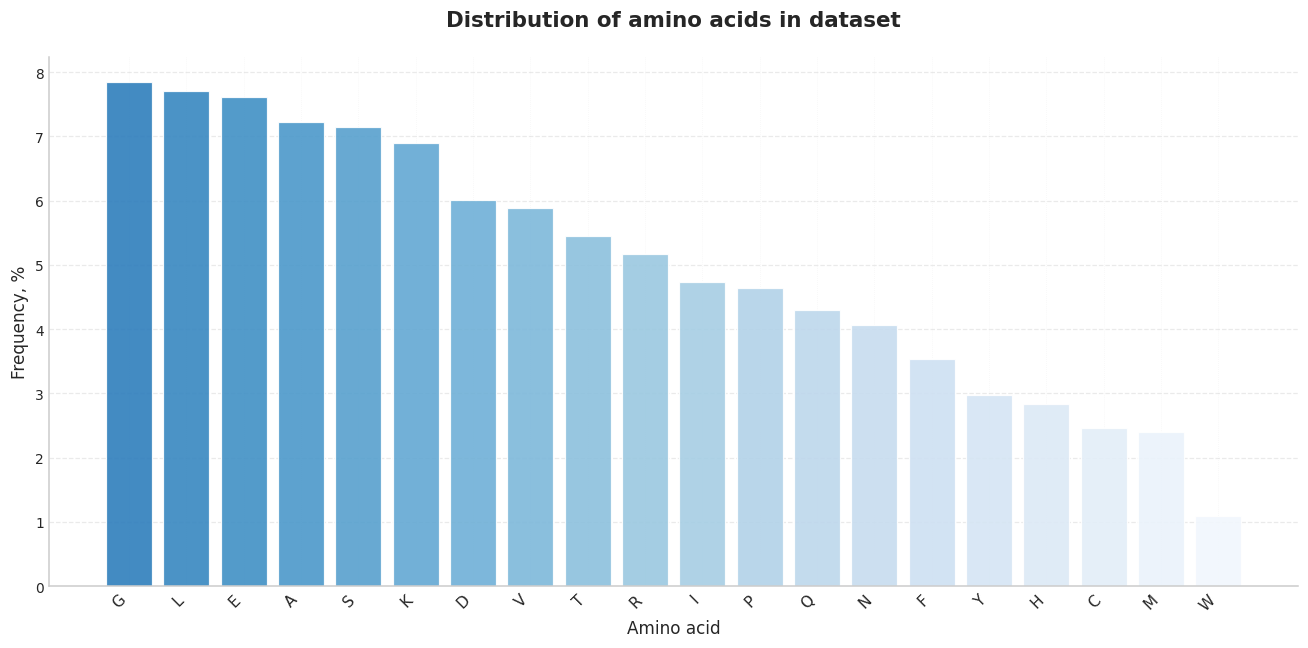


⚠️  ВНИМАНИЕ: Дисбаланс классов = 7.2×
   Рассмотрите добавление class_weights в cross_entropy!


In [31]:
#!/usr/bin/env python3
"""
Анализ распределения аминокислот в датасете MLP.
"""
import torch
from collections import Counter
import matplotlib.pyplot as plt

# Настройка стиля для красивого графика
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

# Пути к файлам
REGISTRY_PATH = "/home/domain/data/aristowi/mlp_dataset_laproteina/latents/registry_with_full_coords.pt"
PAIRS_PATH = "/home/domain/aristowi/la-proteina-main/mlp_model_dataset/train_pairs_clean.pt"

# Маппинг индексов в однобуквенные коды (как у тебя в MLPDataset)
INT_TO_AA = {
    0:"A", 1:"R", 2:"N", 3:"D", 4:"C", 5:"Q", 6:"E", 7:"G", 8:"H", 9:"I",
    10:"L", 11:"K", 12:"M", 13:"F", 14:"P", 15:"S", 16:"T", 17:"W", 18:"Y", 19:"V"
}

def analyze_aa_distribution():
    print("🔍 Загрузка данных...")
    
    # Загружаем registry (может быть большим, используем mmap если нужно)
    registry = torch.load(REGISTRY_PATH, map_location="cpu")
    pairs_data = torch.load(PAIRS_PATH, map_location="cpu")
    pairs = pairs_data["pairs"]
    
    print(f"📦 Registry: {len(registry)} записей")
    print(f"📦 Пар в датасете: {len(pairs)}")
    
    # Счётчик аминокислот
    aa_counter = Counter()
    total_residues = 0
    
    print("🔄 Подсчёт аминокислот...")
    for idx, pair in enumerate(pairs):
        if idx % 1000 == 0 and idx > 0:
            print(f"   Обработано {idx}/{len(pairs)} пар...")
        
        # Получаем индексы белков из пары
        id_a, id_b = registry[pair["a"]], registry[pair["b"]]
        
        # Собираем последовательности (если есть)
        for entry in [id_a, id_b]:
            seq_str = entry.get("sequence", "")
            if isinstance(seq_str, str) and seq_str:
                for aa in seq_str.upper():
                    if aa in INT_TO_AA.values():  # только канонические 20 АК
                        aa_counter[aa] += 1
                        total_residues += 1
    
    # 📊 Статистика
    print(f"\n✅ Всего остатков: {total_residues:,}")
    print(f"✅ Уникальных АК: {len(aa_counter)}/20\n")
    
    # Сортируем по частоте
    sorted_aa = sorted(aa_counter.items(), key=lambda x: x[1], reverse=True)
    
    print("📈 Распределение аминокислот:")
    print(f"{'АК':<4} {'Количество':>12} {'Частота (%)':>14} {'Ожид.*':>10}")
    print("-" * 45)
    
    # Ожидаемая частота при равномерном распределении
    expected_freq = 100.0 / 20
    
    for aa, count in sorted_aa:
        freq = 100.0 * count / total_residues
        print(f"{aa:<4} {count:>12,} {freq:>13.2f}% {expected_freq:>9.2f}%")
    
    # 🎨 Визуализация (ОДИН ГРАФИК)
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Данные для графика
    aa_names = [aa for aa, _ in sorted_aa]
    aa_freqs = [100.0 * aa_counter[aa] / total_residues for aa in aa_names]
    
    # Красивая цветовая схема (градиент от синего к бирюзовому)
    colors = plt.cm.Blues_r([0.3 + 0.7 * i / len(aa_names) for i in range(len(aa_names))])
    
    # Построение столбчатой диаграммы
    bars = ax.bar(range(len(aa_names)), aa_freqs, 
                  color=colors, 
                  edgecolor='navy', 
                  linewidth=1.2,
                  alpha=0.9)
    
    # Подписи осей и заголовок
    ax.set_xlabel("Amino acid", fontsize=11, fontweight='medium')
    ax.set_ylabel("Frequency, %", fontsize=11, fontweight='medium')
    ax.set_title("Distribution of amino acids in dataset", 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Настройка осей
    ax.set_xticks(range(len(aa_names)))
    ax.set_xticklabels(aa_names, rotation=45, ha='right', fontsize=10)
    ax.set_axisbelow(True)  # Сетка позади столбцов
    
    # Улучшенная сетка
    ax.grid(axis='y', linestyle='--', alpha=0.4, linewidth=0.8)
    ax.grid(axis='x', linestyle=':', alpha=0.2, linewidth=0.5)
    
    # Лёгкая тень для столбцов
    for bar in bars:
        bar.set_edgecolor('white')
        bar.set_linewidth(0.8)
    
    # Автоматическая подгонка макета
    plt.tight_layout()
    
    # Сохранение и отображение
    plt.savefig("aa_distribution.png", dpi=300, bbox_inches='tight', facecolor='white')
    print("\n📊 График сохранён в 'aa_distribution.png'")
    plt.show()
    
    # ⚠️ Предупреждение о дисбалансе
    max_freq = max(aa_freqs)
    min_freq = min(aa_freqs)
    imbalance_ratio = max_freq / (min_freq + 1e-6)
    
    if imbalance_ratio > 5:
        print(f"\n⚠️  ВНИМАНИЕ: Дисбаланс классов = {imbalance_ratio:.1f}×")
        print("   Рассмотрите добавление class_weights в cross_entropy!")
    else:
        print(f"\n✅ Дисбаланс классов умеренный: {imbalance_ratio:.1f}×")

if __name__ == "__main__":
    analyze_aa_distribution()

Train: 40 эпох | Val: 40 эпох | Test: 1 строка
Диапазон эпох: 0 – 39


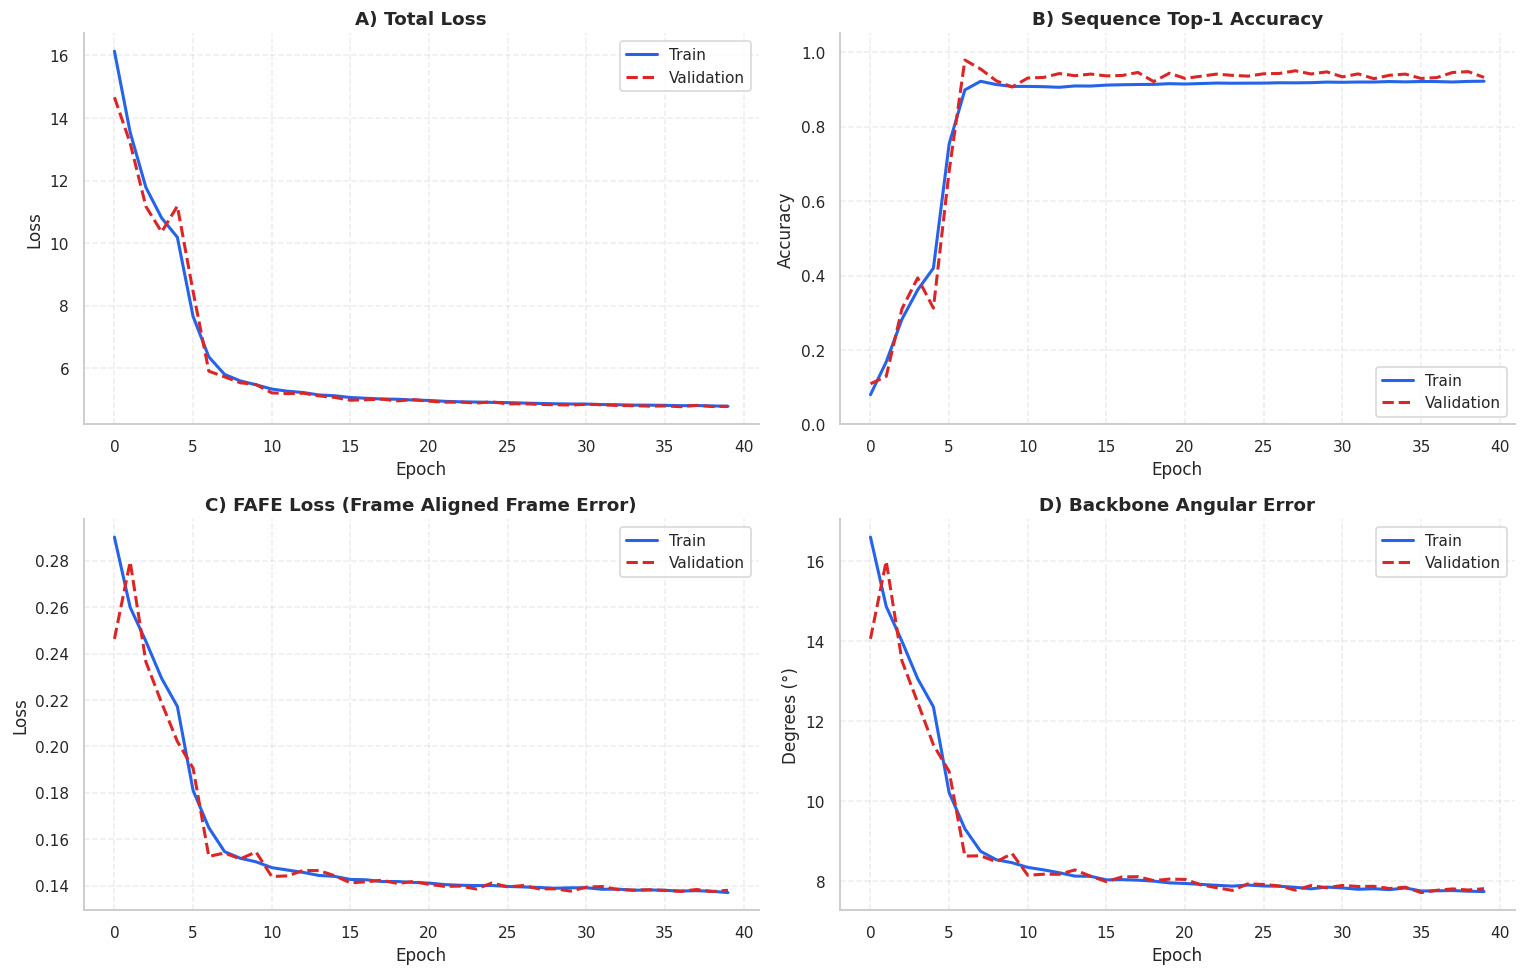

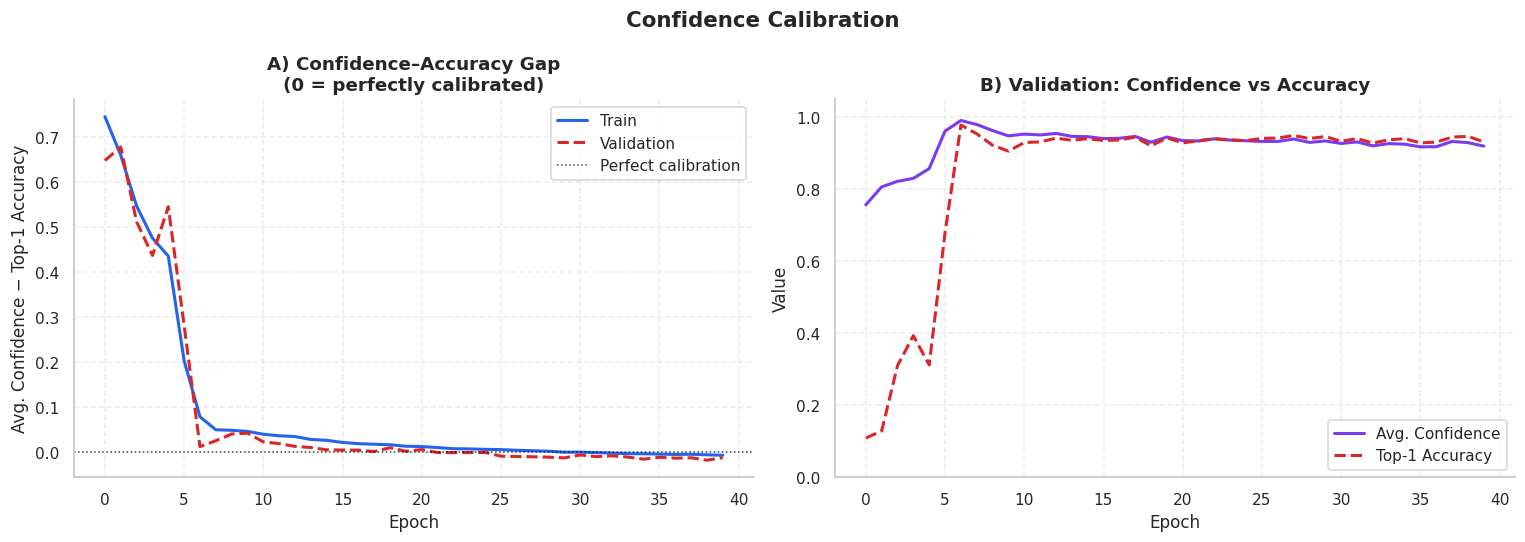

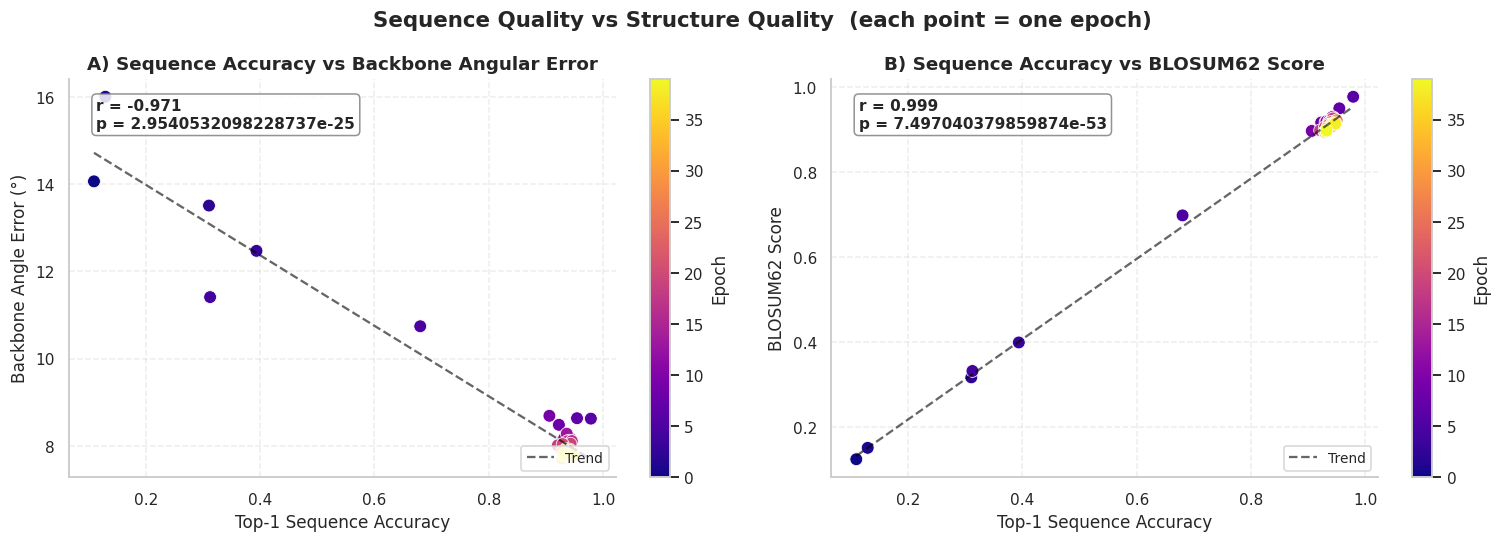

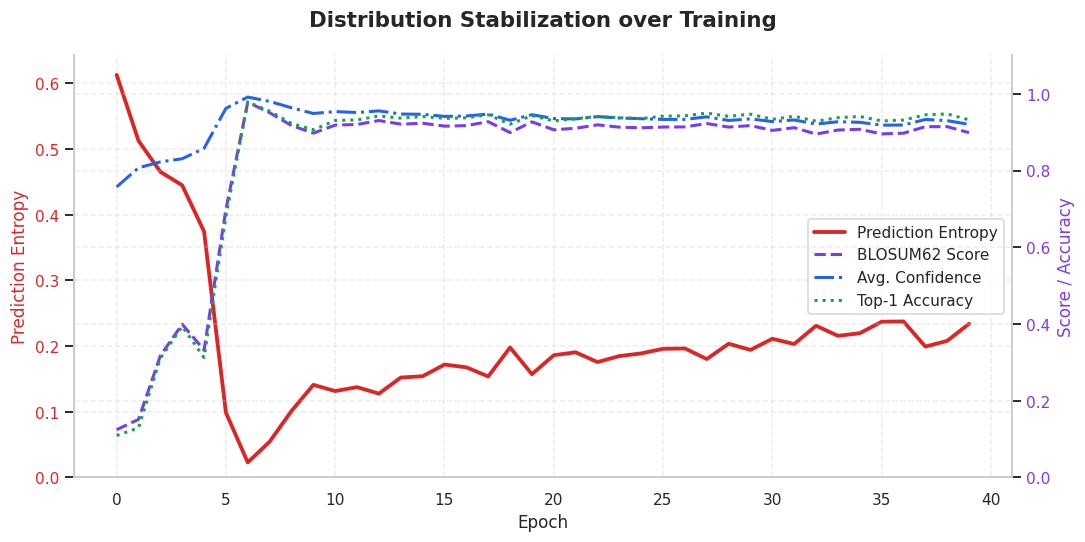

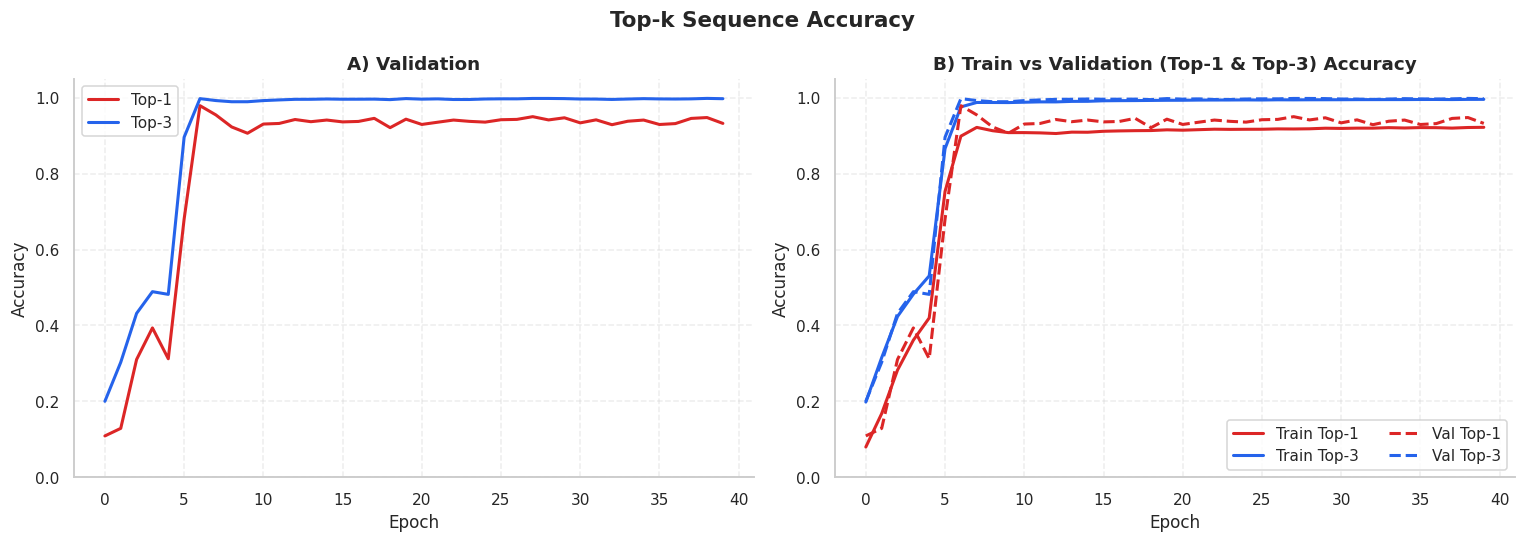

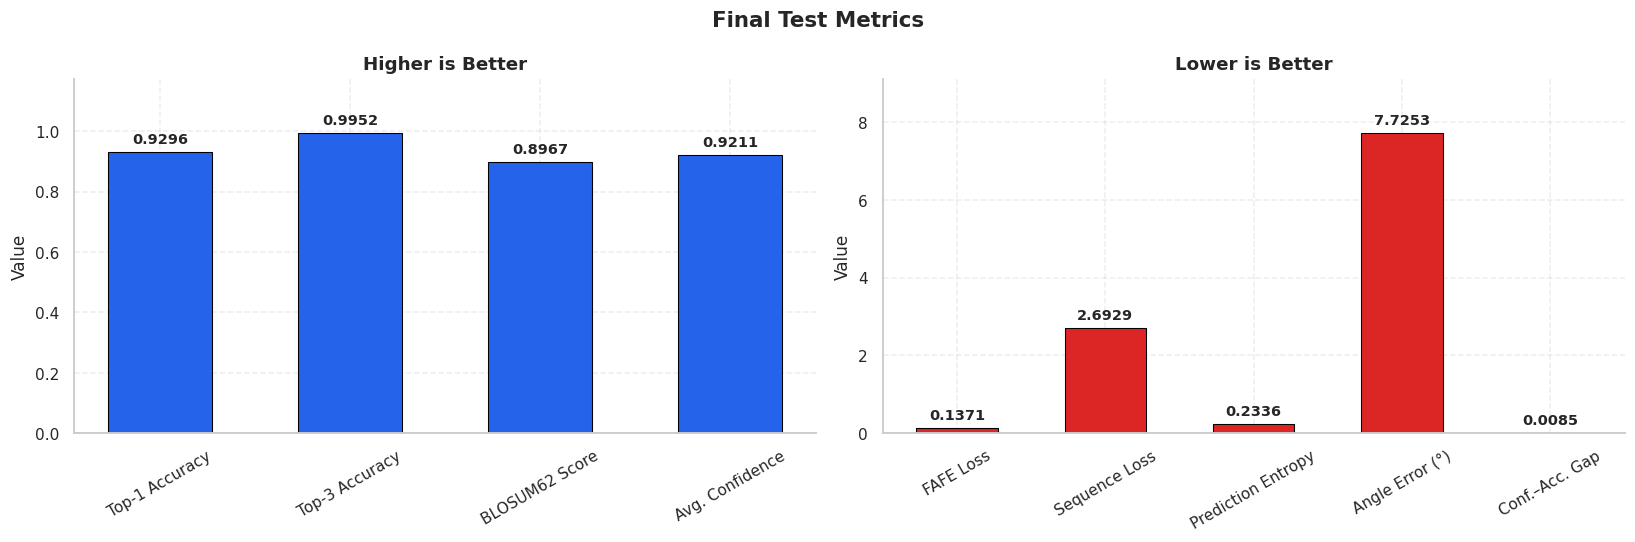


✅ Все 6 графиков построены и сохранены.


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# НАСТРОЙКИ
# ─────────────────────────────────────────────────────────────────────────────
METRICS_CSV = "./csv_logs/mlp_mixer/version_55/metrics.csv"   # ← путь к файлу

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "font.size":        11,
    "axes.titlesize":   12,
    "axes.labelsize":   11,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "legend.fontsize":  10,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.35,
    "grid.linestyle":   "--",
    "figure.dpi":       110,
    "savefig.dpi":      200,
    "savefig.bbox":     "tight",
})

TRAIN_COLOR = "#2563EB"   # синий
VAL_COLOR   = "#DC2626"   # красный
TEST_COLOR  = "#16A34A"   # зелёный

# ─────────────────────────────────────────────────────────────────────────────
# ЗАГРУЗКА ДАННЫХ
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv(METRICS_CSV)

# Train: одна строка на эпоху — берём _epoch-колонки + редкие без суффикса
train_epoch_cols = [c for c in df.columns if c.startswith("train/") and c.endswith("_epoch")]
train_bare_cols  = [c for c in df.columns if c.startswith("train/")
                    and not c.endswith("_epoch") and not c.endswith("_step")]

all_train_cols = train_epoch_cols + train_bare_cols
train = (
    df[["epoch"] + all_train_cols]
    .dropna(subset=all_train_cols, how="all")
    .groupby("epoch").first()
    .reset_index()
)
train.columns = [c.replace("_epoch", "") if c.endswith("_epoch") else c
                 for c in train.columns]

# Val: одна строка на эпоху
val_cols = [c for c in df.columns if c.startswith("val/")]
val = (
    df[["epoch"] + val_cols]
    .dropna(subset=val_cols, how="all")
    .groupby("epoch").first()
    .reset_index()
)

# Test: одна строка
test_cols = [c for c in df.columns if c.startswith("test/")]
test_row = (
    df[test_cols]
    .dropna(how="all")
    .iloc[-1]
)

ep_t = train["epoch"]
ep_v = val["epoch"]

print(f"Train: {len(train)} эпох | Val: {len(val)} эпох | Test: 1 строка")
print(f"Диапазон эпох: {ep_v.min()} – {ep_v.max()}")


# ─────────────────────────────────────────────────────────────────────────────
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ─────────────────────────────────────────────────────────────────────────────
def plot_pair(ax, ep_t, t_series, ep_v, v_series,
              ylabel, title, ylim=None):
    """Рисует пару train/val кривых на одной оси."""
    mask_t = t_series.notna()
    mask_v = v_series.notna()

    if mask_t.any():
        ax.plot(ep_t[mask_t], t_series[mask_t],
                color=TRAIN_COLOR, lw=2, label="Train")
    if mask_v.any():
        ax.plot(ep_v[mask_v], v_series[mask_v],
                color=VAL_COLOR, lw=2, label="Validation", ls="--")

    ax.set_title(title, fontweight="bold", pad=6)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)
    ax.legend(frameon=True)


def pvalue_str(p):
    """Форматирует p-value в читаемый вид."""
    p_str = f"p = {p}"
    return p_str


def scatter_with_stats(ax, x_vals, y_vals, epoch_vals, xlabel, ylabel, title, cmap):
    """
    Scatter plot с линией тренда, коэффициентом Пирсона и p-value.
    Возвращает объект scatter для colorbar.
    """
    sc = ax.scatter(
        x_vals, y_vals,
        c=epoch_vals, cmap=cmap,
        s=70, edgecolors="white", lw=0.5, zorder=3
    )

    # Линия тренда
    z = np.polyfit(x_vals, y_vals, 1)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
    ax.plot(x_line, np.poly1d(z)(x_line),
            color="black", lw=1.5, ls="--", alpha=0.6, zorder=4, label="Trend")

    # Pearson r и p-value
    r, p = stats.pearsonr(x_vals, y_vals)
    annotation = f"r = {r:.3f}\n{pvalue_str(p)}"
    ax.text(0.05, 0.95, annotation,
            transform=ax.transAxes,
            fontsize=10, fontweight="bold",
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="gray", alpha=0.85))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.legend(frameon=True, loc="lower right", fontsize=9)
    return sc


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 1: Кривые обучения — 4 панели
# ═════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_pair(axes[0, 0],
          ep_t, train["train/total_loss"],
          ep_v, val["val/total_loss"],
          ylabel="Loss", title="A) Total Loss")

plot_pair(axes[0, 1],
          ep_t, train["train/seq_top1_acc"],
          ep_v, val["val/seq_top1_acc"],
          ylabel="Accuracy", title="B) Sequence Top-1 Accuracy",
          ylim=(0.0, 1.05))

plot_pair(axes[1, 0],
          ep_t, train["train/loss_fafe"],
          ep_v, val["val/loss_fafe"],
          ylabel="Loss", title="C) FAFE Loss (Frame Aligned Frame Error)")

plot_pair(axes[1, 1],
          ep_t, train["train/geom_angle_deg"],
          ep_v, val["val/geom_angle_deg"],
          ylabel="Degrees (°)", title="D) Backbone Angular Error")

plt.tight_layout()
plt.savefig("Fig1_Training_Curves.png")
plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 2: Калибровка уверенности
# ═════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confidence Calibration", fontsize=14, fontweight="bold")

# Панель A: Train/Val conf_acc_gap
ax = axes[0]
mask_t = train["train/conf_acc_gap"].notna()
mask_v = val["val/conf_acc_gap"].notna()
if mask_t.any():
    ax.plot(ep_t[mask_t], train["train/conf_acc_gap"][mask_t],
            color=TRAIN_COLOR, lw=2, label="Train")
if mask_v.any():
    ax.plot(ep_v[mask_v], val["val/conf_acc_gap"][mask_v],
            color=VAL_COLOR, lw=2, ls="--", label="Validation")
ax.axhline(0, color="black", lw=1, ls=":", alpha=0.7, label="Perfect calibration")
ax.set_title("A) Confidence–Accuracy Gap\n(0 = perfectly calibrated)", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Avg. Confidence − Top-1 Accuracy")
ax.legend(frameon=True)

# Панель B: Val confidence vs val accuracy
ax = axes[1]
mask_c = val["val/avg_confidence"].notna()
mask_a = val["val/seq_top1_acc"].notna()
if mask_c.any():
    ax.plot(ep_v[mask_c], val["val/avg_confidence"][mask_c],
            color="#7C3AED", lw=2, label="Avg. Confidence")
if mask_a.any():
    ax.plot(ep_v[mask_a], val["val/seq_top1_acc"][mask_a],
            color=VAL_COLOR, lw=2, ls="--", label="Top-1 Accuracy")
ax.set_title("B) Validation: Confidence vs Accuracy", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Value")
ax.set_ylim(0, 1.05)
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig("Fig2_Calibration.png")
plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 3: Scatter — точность vs качество структуры (по эпохам)
# ═════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sequence Quality vs Structure Quality  (each point = one epoch)",
             fontsize=14, fontweight="bold")

cmap = plt.cm.plasma

# 3A: Top-1 Acc vs Angular Error
mask = val["val/seq_top1_acc"].notna() & val["val/geom_angle_deg"].notna()
sc = scatter_with_stats(
    ax=axes[0],
    x_vals=val["val/seq_top1_acc"][mask].values,
    y_vals=val["val/geom_angle_deg"][mask].values,
    epoch_vals=ep_v[mask].values,
    xlabel="Top-1 Sequence Accuracy",
    ylabel="Backbone Angle Error (°)",
    title="A) Sequence Accuracy vs Backbone Angular Error",
    cmap=cmap,
)
plt.colorbar(sc, ax=axes[0], label="Epoch")

# 3B: Top-1 Acc vs BLOSUM62
mask = val["val/seq_top1_acc"].notna() & val["val/blosum62_score"].notna()
sc = scatter_with_stats(
    ax=axes[1],
    x_vals=val["val/seq_top1_acc"][mask].values,
    y_vals=val["val/blosum62_score"][mask].values,
    epoch_vals=ep_v[mask].values,
    xlabel="Top-1 Sequence Accuracy",
    ylabel="BLOSUM62 Score",
    title="B) Sequence Accuracy vs BLOSUM62 Score",
    cmap=cmap,
)
plt.colorbar(sc, ax=axes[1], label="Epoch")

plt.tight_layout()
plt.savefig("Fig3_Scatter.png")
plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 4: Энтропия, уверенность и BLOSUM по эпохам
# ═════════════════════════════════════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(10, 5))
fig.suptitle("Distribution Stabilization over Training", fontsize=14, fontweight="bold")

color_ent = "#DC2626"
mask = val["val/pred_entropy"].notna()
ax1.plot(ep_v[mask], val["val/pred_entropy"][mask],
         color=color_ent, lw=2.5, label="Prediction Entropy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Prediction Entropy", color=color_ent)
ax1.tick_params(axis="y", labelcolor=color_ent)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.spines["right"].set_visible(True)

mask_b = val["val/blosum62_score"].notna()
mask_c = val["val/avg_confidence"].notna()
mask_a = val["val/seq_top1_acc"].notna()

ax2.plot(ep_v[mask_b], val["val/blosum62_score"][mask_b],
         color="#7C3AED", lw=2, ls="--", label="BLOSUM62 Score")
ax2.plot(ep_v[mask_c], val["val/avg_confidence"][mask_c],
         color="#2563EB", lw=2, ls="-.", label="Avg. Confidence")
ax2.plot(ep_v[mask_a], val["val/seq_top1_acc"][mask_a],
         color="#16A34A", lw=2, ls=":", label="Top-1 Accuracy")
ax2.set_ylabel("Score / Accuracy", color="#7C3AED")
ax2.tick_params(axis="y", labelcolor="#7C3AED")
ax2.set_ylim(0, 1.1)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="center right", frameon=True)

plt.tight_layout()
plt.savefig("Fig4_Entropy_BLOSUM.png")
plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 5: Top-K точность по эпохам
# ═════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Top-k Sequence Accuracy", fontsize=14, fontweight="bold")

topk_colors = {"Top-1": "#DC2626", "Top-3": "#2563EB"}
topk_val_cols = {
    "Top-1": "val/seq_top1_acc",
    "Top-3": "val/seq_top3_acc",
}
topk_train_cols = {
    "Top-1": "train/seq_top1_acc",
    "Top-3": "train/seq_top3_acc",
}

# Панель A: Validation
ax = axes[0]
for label, col in topk_val_cols.items():
    if col in val.columns:
        mask = val[col].notna()
        ax.plot(ep_v[mask], val[col][mask],
                color=topk_colors[label], lw=2, label=label)
ax.set_title("A) Validation", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.0, 1.05)
ax.legend(frameon=True)

# Панель B: Train vs Val
ax = axes[1]
for label in ["Top-1", "Top-3"]:
    col = topk_train_cols[label]
    if col in train.columns:
        mask = train[col].notna()
        ax.plot(ep_t[mask], train[col][mask],
                color=topk_colors[label], lw=2, label=f"Train {label}")
for label in ["Top-1", "Top-3"]:
    col = topk_val_cols[label]
    if col in val.columns:
        mask = val[col].notna()
        ax.plot(ep_v[mask], val[col][mask],
                color=topk_colors[label], lw=2, ls="--", label=f"Val {label}")
ax.set_title("B) Train vs Validation (Top-1 & Top-3) Accuracy", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.0, 1.05)
ax.legend(frameon=True, ncol=2)

plt.tight_layout()
plt.savefig("Fig5_TopK.png")
plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 6: Итоговые метрики на тестовой выборке (bar chart)
# ═════════════════════════════════════════════════════════════════════════════
metrics_higher = {
    "Top-1 Accuracy":  test_row.get("test/seq_top1_acc",   np.nan),
    "Top-3 Accuracy":  test_row.get("test/seq_top3_acc",   np.nan),
    "BLOSUM62 Score":  test_row.get("test/blosum62_score",  np.nan),
    "Avg. Confidence": test_row.get("test/avg_confidence",  np.nan),
}
metrics_lower = {
    "FAFE Loss":          test_row.get("test/loss_fafe",       np.nan),
    "Sequence Loss":      test_row.get("test/loss_seq",        np.nan),
    "Prediction Entropy": test_row.get("test/pred_entropy",    np.nan),
    "Angle Error (°)":    test_row.get("test/geom_angle_deg",  np.nan),
    "Conf.–Acc. Gap": abs(test_row.get("test/conf_acc_gap", np.nan)),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Final Test Metrics", fontsize=14, fontweight="bold")

def _bar_panel(ax, metrics_dict, title, color):
    keys = [k for k, v in metrics_dict.items() if pd.notna(v)]
    vals = [metrics_dict[k] for k in keys]
    bars = ax.bar(keys, vals, color=color, edgecolor="black", lw=0.7, width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.02,
                f"{val:.4f}",
                ha="center", va="bottom", fontsize=9.5, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Value")
    ax.set_ylim(0, max(vals) * 1.18)
    ax.tick_params(axis="x", rotation=30)

_bar_panel(axes[0], metrics_higher, "Higher is Better", "#2563EB")
_bar_panel(axes[1], metrics_lower,  "Lower is Better",  "#DC2626")

plt.tight_layout()
plt.savefig("Fig6_Test_Metrics.png")
plt.show()

print("\n✅ Все 6 графиков построены и сохранены.")

In [ ]:
CONFIG = {
    "exp_mlp_on": "../inference/inference_ucond_tri_result_mlpon_0909",      # Папка с режимом α=0.9, MLP ✅
    "exp_mlp_off_09": "../inference/inference_ucond_tri",   # Папка с режимом α=0.9, MLP ❌
    "exp_avg_05": "../inference/inference_ucond_tri_result_mlpoff_0505",           # Папка с режимом α=0.5, MLP ❌
    "output_dir": "./analysis_output",          # Куда сохранять отчёты и графики
    "pdb_ext": "*.pdb"       
}               # Расширение файлов структур

📥 Загрузка и верификация данных...

📂 Сканирование: ../inference/inference_ucond_tri_result_mlpon_0909 (100 папок)

🔍 Парсинг пары 0 (job_0_n_120_id_0):
  📄 job_0_n_120_id_0_pathA.pdb: прочитано 120 ост. | seq[:20]=MKNEELINLLEELKPDAIIL
  📄 job_0_n_120_id_0_pathB.pdb: прочитано 120 ост. | seq[:20]=MKNEELINLLEELKPDAIIL
  ✅ SeqID=97.5% | RMSD=13.83Å

🔍 Парсинг пары 1 (job_0_n_120_id_1):
  📄 job_0_n_120_id_1_pathA.pdb: прочитано 120 ост. | seq[:20]=MNEKEKKLLEDAINHLLKQE
  📄 job_0_n_120_id_1_pathB.pdb: прочитано 120 ост. | seq[:20]=MNIKEKKLLEDAINHLLKQE
  ✅ SeqID=95.8% | RMSD=14.25Å

🔍 Парсинг пары 2 (job_0_n_120_id_10):
  📄 job_0_n_120_id_10_pathA.pdb: прочитано 120 ост. | seq[:20]=MREQQEEVIEYLLEKGYKVT
  📄 job_0_n_120_id_10_pathB.pdb: прочитано 120 ост. | seq[:20]=MREQQEEVIEYLLEVGYKVT
  ✅ SeqID=99.2% | RMSD=13.63Å

🔍 Парсинг пары 3 (job_0_n_120_id_11):
  📄 job_0_n_120_id_11_pathA.pdb: прочитано 120 ост. | seq[:20]=MTKIRDLLDEIEDEEDREEL
  📄 job_0_n_120_id_11_pathB.pdb: прочитано 120 ост. | seq

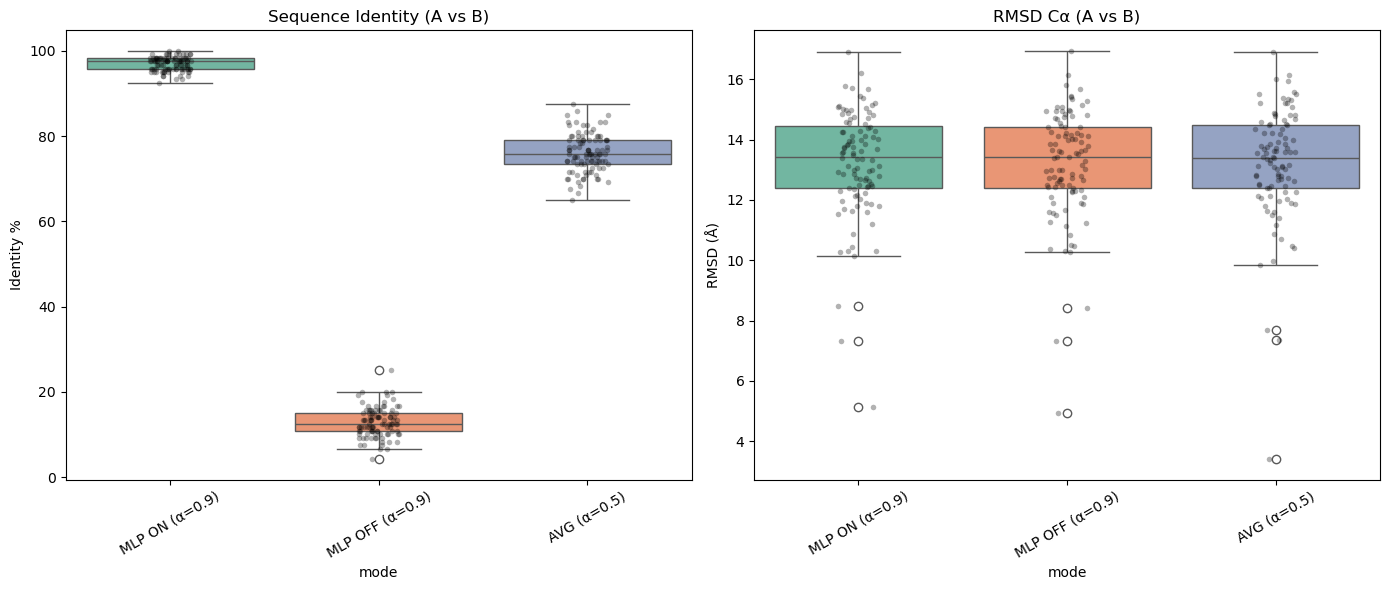


🏁 Анализ завершён!


In [9]:
%matplotlib inline
import os, warnings, re
from pathlib import Path
from typing import Dict, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats

warnings.filterwarnings("ignore")

# ==========================================================
# ⚙️ КОНФИГУРАЦИЯ (ИЗМЕНИТЕ ПУТИ)
# ==========================================================
CONFIG = {
    "exp_mlp_on": "../inference/inference_ucond_tri_result_mlpon_0909",      # Папка с режимом α=0.9, MLP ✅
    "exp_mlp_off_09": "../inference/inference_ucond_tri",   # Папка с режимом α=0.9, MLP ❌
    "exp_avg_05": "../inference/inference_ucond_tri_result_mlpoff_0505",           # Папка с режимом α=0.5, MLP ❌
    "output_dir": "./analysis_output",          # Куда сохранять отчёты и графики
    "pdb_ext": "*.pdb"       
}
os.makedirs(CONFIG["output_dir"], exist_ok=True)

# ==========================================================
# 🔧 НАДЁЖНЫЕ УТИЛИТЫ (Прямое чтение ATOM, без Bio.PDB)
# ==========================================================
def read_sequence_from_pdb(pdb_path: str, verbose: bool = False) -> Optional[str]:
    """Читает последовательность напрямую из ATOM записей (CA). Работает на любых сгенерированных PDB."""
    seq = []
    t1 = {'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E','GLY':'G',
          'HIS':'H','ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S',
          'THR':'T','TRP':'W','TYR':'Y','VAL':'V'}
    try:
        with open(pdb_path, 'r') as f:
            for line in f:
                if line.startswith("ATOM") and len(line) > 20:
                    atom_name = line[12:16].strip()
                    res_name = line[17:20].strip()
                    if atom_name == "CA" and res_name in t1:
                        seq.append(t1[res_name])
        result = "".join(seq)
        if verbose: print(f"  📄 {os.path.basename(pdb_path)}: прочитано {len(result)} ост. | seq[:20]={result[:20]}")
        return result if result else None
    except Exception as e:
        if verbose: print(f"  ❌ Ошибка чтения {pdb_path}: {e}")
        return None

def read_ca_coords_from_pdb(pdb_path: str) -> Optional[np.ndarray]:
    """Читает координаты Cα напрямую из ATOM записей."""
    coords = []
    try:
        with open(pdb_path, 'r') as f:
            for line in f:
                if line.startswith("ATOM") and line[12:16].strip() == "CA":
                    try:
                        x = float(line[30:38])
                        y = float(line[38:46])
                        z = float(line[46:54])
                        coords.append([x, y, z])
                    except: pass
        return np.array(coords, dtype=np.float32) if coords else None
    except: return None

def compute_seq_identity(seq_a: str, seq_b: str) -> float:
    if not seq_a or not seq_b: return 0.0
    n = min(len(seq_a), len(seq_b))
    if n == 0: return 0.0
    # Жёсткое попарное сравнение
    matches = sum(1 for a, b in zip(seq_a[:n], seq_b[:n]) if a == b)
    return (matches / n) * 100.0

def compute_rmsd(coords_a: np.ndarray, coords_b: np.ndarray) -> float:
    if coords_a is None or coords_b is None or len(coords_a) != len(coords_b) or len(coords_a) == 0:
        return np.nan
    ca, cb = coords_a - coords_a.mean(axis=0), coords_b - coords_b.mean(axis=0)
    H = ca.T @ cb
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0: Vt[-1, :] *= -1; R = Vt.T @ U.T
    return np.sqrt(np.mean(np.sum((ca - cb @ R)**2, axis=1)))

def load_experiment_data(root_path: str, ext: str = "*.pdb", debug: bool = True) -> pd.DataFrame:
    records, root = [], Path(root_path)
    if not root.exists(): 
        print(f"⚠️ Папка не найдена: {root_path}")
        return pd.DataFrame()
    
    subdirs = sorted([d for d in root.iterdir() if d.is_dir()])
    print(f"\n📂 Сканирование: {root_path} ({len(subdirs)} папок)")
    
    processed, failed = 0, 0
    for idx, subdir in enumerate(subdirs):
        files = sorted(list(subdir.glob(ext)))
        if len(files) < 2:
            failed += 1
            continue
            
        # Жёсткий поиск файлов A и B
        f_a = next((f for f in files if re.search(r'[_\-]a', f.stem, re.I)), files[0])
        f_b = next((f for f in files if re.search(r'[_\-]b', f.stem, re.I)), files[1] if len(files)>1 else None)
        
        if not f_b: failed += 1; continue
        
        if debug and idx < 5:
            print(f"\n🔍 Парсинг пары {idx} ({subdir.name}):")
            
        s_a = read_sequence_from_pdb(str(f_a), verbose=debug and idx < 5)
        s_b = read_sequence_from_pdb(str(f_b), verbose=debug and idx < 5)
        c_a = read_ca_coords_from_pdb(str(f_a))
        c_b = read_ca_coords_from_pdb(str(f_b))
        
        if s_a and s_b and c_a is not None and c_b is not None:
            sid = compute_seq_identity(s_a, s_b)
            rmsd = compute_rmsd(c_a, c_b)
            records.append({
                'sample_id': subdir.name, 'seq_identity': sid,
                'rmsd_ca': rmsd, 'len_a': len(s_a), 'len_b': len(s_b)
            })
            processed += 1
            if debug and idx < 5:
                print(f"  ✅ SeqID={sid:.1f}% | RMSD={rmsd:.2f}Å")
                if sid == 100.0:
                    print(f"  ⚠️ ВНИМАНИЕ: 100% совпадение! Проверьте файлы: {f_a.name} vs {f_b.name}")
        else:
            failed += 1
            if debug and idx < 5: print(f"  ❌ Не удалось прочитать метрики (s_a={s_a is not None}, s_b={s_b is not None})")
            
    df = pd.DataFrame(records)
    print(f"📊 Итог: обработано {processed}, пропущено {failed}")
    return df

# ==========================================================
# 📊 СТАТИСТИКА, ОТЧЁТ И ГРАФИКИ
# ==========================================================
def run_statistics(dfs: Dict[str, pd.DataFrame]) -> Dict:
    res = {}
    group_names = list(dfs.keys())
    n_groups = len(group_names)
    for metric in ['seq_identity', 'rmsd_ca']:
        groups = [df[metric].dropna().values for df in dfs.values()]
        groups = [g for g in groups if len(g) > 0]
        p_overall = scipy_stats.kruskal(*groups).pvalue if len(groups) >= 2 else 1.0
        pairwise_results = []
        n_tests = n_groups * (n_groups - 1) // 2
        alpha_bonf = 0.05 / n_tests if n_tests > 0 else 0.05
        for i in range(n_groups):
            for j in range(i + 1, n_groups):
                g1 = dfs[group_names[i]][metric].dropna()
                g2 = dfs[group_names[j]][metric].dropna()
                if len(g1) > 0 and len(g2) > 0:
                    stat, p_raw = scipy_stats.mannwhitneyu(g1, g2, alternative='two-sided')
                    pairwise_results.append({
                        'Group1': group_names[i], 'Group2': group_names[j],
                        'MeanDiff': g1.mean() - g2.mean(),
                        'P-raw': p_raw, 'P-bonf': min(1.0, p_raw * n_tests), 'Reject': p_raw < alpha_bonf
                    })
        res[metric] = {'p_overall': p_overall, 'pairwise': pd.DataFrame(pairwise_results)}
    return res

def generate_report_and_plots(dfs: Dict[str, pd.DataFrame], stats_res: Dict, out_dir: str):
    """Форматирует p-value точно: 4 знака для обычных значений, научная нотация для очень малых."""
    
    def format_pvalue(p: float) -> str:
        """Точное форматирование p-value."""
        if p >= 0.0001:
            return f"{p:.4f}"
        elif p > 0:
            return f"{p:.2e}"  # Научная нотация: 1.23e-05
        else:
            return "0.0000"
    
    report_path = os.path.join(out_dir, "analysis_report.txt")
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("🔬 АНАЛИЗ ПАРНЫХ СТРУКТУР (A vs B)\n" + "="*50 + "\n")
        
        for metric, label in [('seq_identity', 'Sequence Identity (%)'), ('rmsd_ca', 'RMSD Cα (Å)')]:
            f.write(f"\n{label} (Kruskal-Wallis p={format_pvalue(stats_res[metric]['p_overall'])}):\n")
            for name, df in dfs.items():
                if metric in df.columns and len(df) > 0:
                    f.write(f"  • {name}: {df[metric].mean():.2f} ± {df[metric].std():.2f} (n={len(df)})\n")
                    
            f.write("  Попарные сравнения (Mann-Whitney U + Bonferroni α=0.0167):\n")
            pdf = stats_res[metric]['pairwise']
            if pdf.empty: 
                f.write("    Недостаточно данных.\n")
            else:
                for _, r in pdf.iterrows():
                    sig = "✅ ЗНАЧИМО" if r['Reject'] else "❌ НЕ ЗНАЧИМО"
                    # Форматируем оба p-value точно
                    p_raw = format_pvalue(r['P-raw'])
                    p_bonf = format_pvalue(r['P-bonf'])
                    f.write(f"    {r['Group1']} vs {r['Group2']}: Δ={r['MeanDiff']:+.3f}, p={p_raw} (bonf={p_bonf}) → {sig}\n")
    
    print(f"✅ Отчёт сохранён: {report_path}")

    # Графики (без изменений)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = sns.color_palette("Set2", len(dfs))
    for i, (metric, title, ylabel) in enumerate([
        ('seq_identity', 'Sequence Identity (A vs B)', 'Identity %'),
        ('rmsd_ca', 'RMSD Cα (A vs B)', 'RMSD (Å)')
    ]):
        ax = axes[i]
        data, labels = [], []
        for name, df in dfs.items():
            if metric in df.columns:
                data.extend(df[metric].tolist())
                labels.extend([name] * len(df))
        if len(data) > 0:
            plot_df = pd.DataFrame({'val': data, 'mode': labels})
            sns.boxplot(x='mode', y='val', data=plot_df, ax=ax, palette=colors)
            sns.stripplot(x='mode', y='val', data=plot_df, ax=ax, color='black', alpha=0.3, size=4)
        ax.set_title(title); ax.set_ylabel(ylabel); ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "comparison_boxplots.png"), dpi=300)
    plt.show()
# ==========================================================
# 🚀 ЗАПУСК
# ==========================================================
print("📥 Загрузка и верификация данных...")
dfs = {
    "MLP ON (α=0.9)": load_experiment_data(CONFIG["exp_mlp_on"], CONFIG["pdb_ext"], debug=True),
    "MLP OFF (α=0.9)": load_experiment_data(CONFIG["exp_mlp_off_09"], CONFIG["pdb_ext"], debug=True),
    "AVG (α=0.5)": load_experiment_data(CONFIG["exp_avg_05"], CONFIG["pdb_ext"], debug=True),
}

print("\n📋 СВОДКА ПО РЕЖИМАМ:")
for name, df in dfs.items():
    if df.empty: print(f"⚠️ {name}: НЕТ ДАННЫХ!")
    else:
        print(f"✅ {name}: {len(df)} пар")
        print(f"   SeqID: min={df['seq_identity'].min():.1f}%, max={df['seq_identity'].max():.1f}%, mean={df['seq_identity'].mean():.1f}%")
        print(f"   RMSD:  min={df['rmsd_ca'].min():.2f} Å, max={df['rmsd_ca'].max():.2f} Å, mean={df['rmsd_ca'].mean():.2f} Å")

print("\n📊 Статистика и графики...")
stats_res = run_statistics(dfs)
generate_report_and_plots(dfs, stats_res, CONFIG["output_dir"])
print("\n🏁 Анализ завершён!")

📥 Загрузка данных...

📂 ../inference/inference_ucond_tri_result_mlpon_0909 (100 папок)
  📄 job_0_n_120_id_0_pathA.pdb: 120 ост.
  📄 job_0_n_120_id_0_pathB.pdb: 120 ост.
  📄 job_0_n_120_id_1_pathA.pdb: 120 ост.
  📄 job_0_n_120_id_1_pathB.pdb: 120 ост.
  📄 job_0_n_120_id_10_pathA.pdb: 120 ост.
  📄 job_0_n_120_id_10_pathB.pdb: 120 ост.
  ✅ обработано: 100, пропущено: 0

📂 ../inference/inference_ucond_tri (100 папок)
  📄 job_0_n_120_id_0_pathA.pdb: 120 ост.
  📄 job_0_n_120_id_0_pathB.pdb: 120 ост.
  📄 job_0_n_120_id_1_pathA.pdb: 120 ост.
  📄 job_0_n_120_id_1_pathB.pdb: 120 ост.
  📄 job_0_n_120_id_10_pathA.pdb: 120 ост.
  📄 job_0_n_120_id_10_pathB.pdb: 120 ост.
  ✅ обработано: 100, пропущено: 0

📂 ../inference/inference_ucond_tri_result_mlpoff_0505 (100 папок)
  📄 job_0_n_120_id_0_pathA.pdb: 120 ост.
  📄 job_0_n_120_id_0_pathB.pdb: 120 ост.
  📄 job_0_n_120_id_1_pathA.pdb: 120 ост.
  📄 job_0_n_120_id_1_pathB.pdb: 120 ост.
  📄 job_0_n_120_id_10_pathA.pdb: 120 ост.
  📄 job_0_n_120_id_10_pathB.

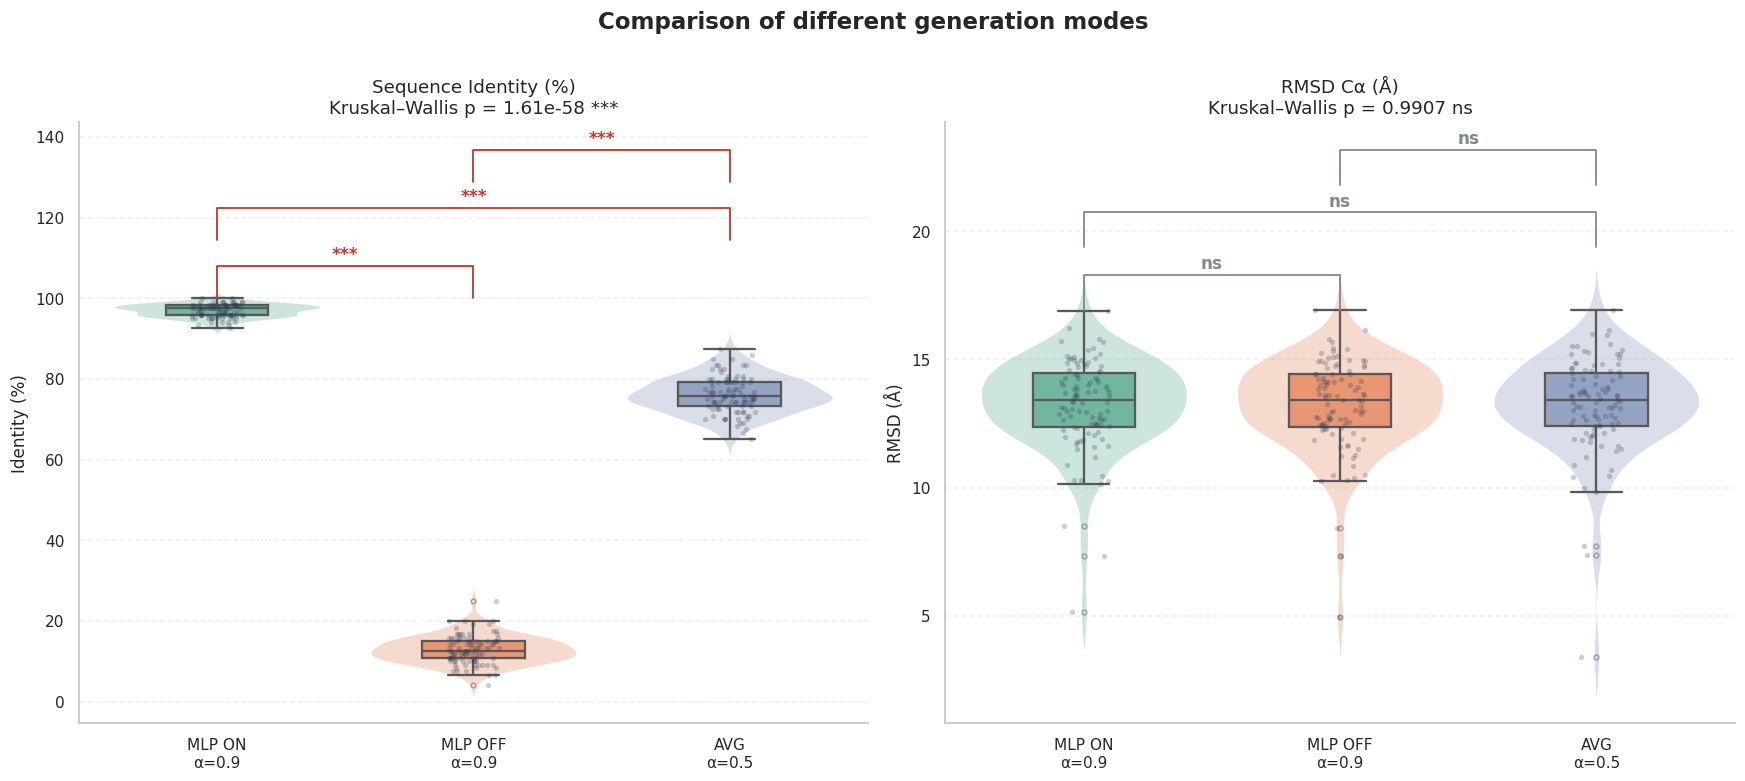

✅ График сохранён: fig_boxplot_pvalue.png


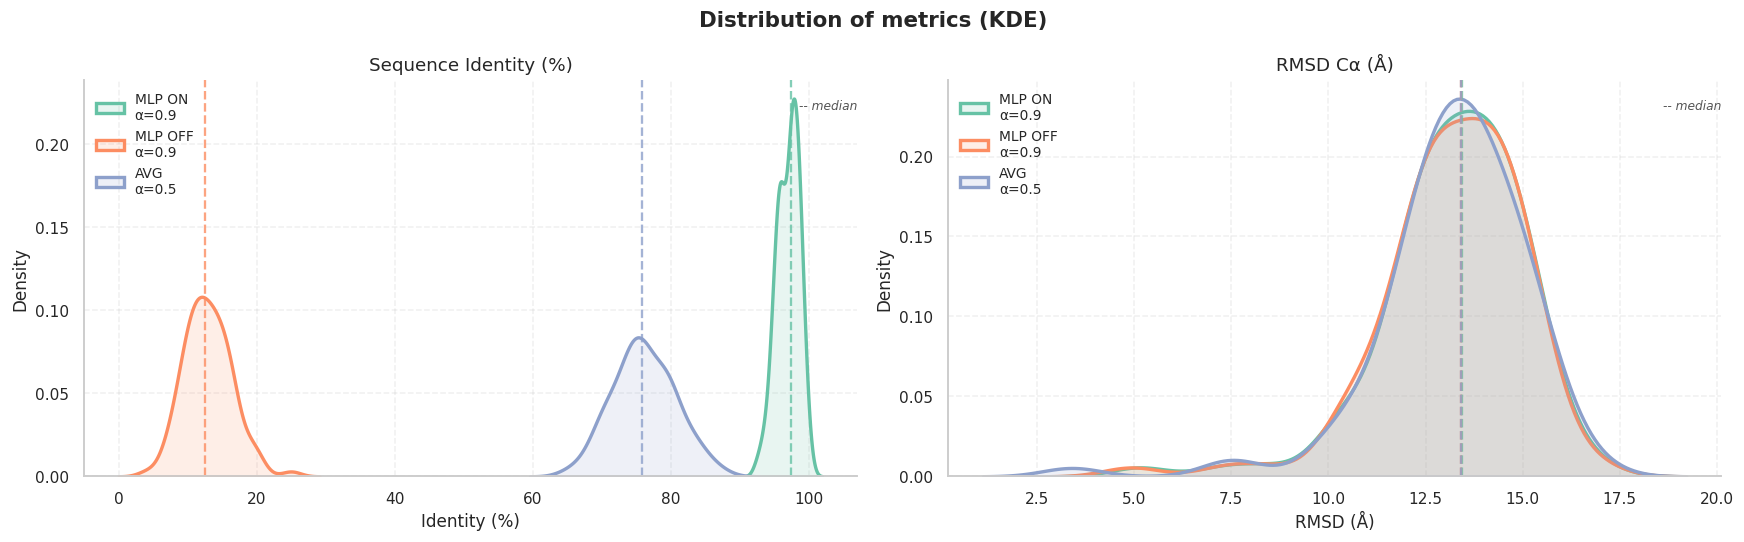

✅ График сохранён: fig_kde_distributions.png

📄 Отчёт...
✅ Отчёт сохранён: ./analysis_output/analysis_report.txt

🏁 Готово!


In [54]:
%matplotlib inline
import os, warnings, re
from pathlib import Path
from typing import Dict, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats as scipy_stats
from itertools import combinations

warnings.filterwarnings("ignore")

# ==========================================================
# ⚙️ КОНФИГУРАЦИЯ
# ==========================================================
CONFIG = {
    "exp_mlp_on":    "../inference/inference_ucond_tri_result_mlpon_0909",
    "exp_mlp_off_09":"../inference/inference_ucond_tri",
    "exp_avg_05":    "../inference/inference_ucond_tri_result_mlpoff_0505",
    "output_dir":    "./analysis_output",
    "pdb_ext":       "*.pdb"
}
os.makedirs(CONFIG["output_dir"], exist_ok=True)

# ==========================================================
# 🔧 УТИЛИТЫ ЧТЕНИЯ PDB (без изменений)
# ==========================================================
def read_sequence_from_pdb(pdb_path: str, verbose: bool = False) -> Optional[str]:
    seq = []
    t1 = {'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E','GLY':'G',
          'HIS':'H','ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S',
          'THR':'T','TRP':'W','TYR':'Y','VAL':'V'}
    try:
        with open(pdb_path, 'r') as f:
            for line in f:
                if line.startswith("ATOM") and len(line) > 20:
                    atom_name = line[12:16].strip()
                    res_name  = line[17:20].strip()
                    if atom_name == "CA" and res_name in t1:
                        seq.append(t1[res_name])
        result = "".join(seq)
        if verbose: print(f"  📄 {os.path.basename(pdb_path)}: {len(result)} ост.")
        return result if result else None
    except Exception as e:
        if verbose: print(f"  ❌ {pdb_path}: {e}")
        return None

def read_ca_coords_from_pdb(pdb_path: str) -> Optional[np.ndarray]:
    coords = []
    try:
        with open(pdb_path, 'r') as f:
            for line in f:
                if line.startswith("ATOM") and line[12:16].strip() == "CA":
                    try:
                        coords.append([float(line[30:38]), float(line[38:46]), float(line[46:54])])
                    except: pass
        return np.array(coords, dtype=np.float32) if coords else None
    except: return None

def compute_seq_identity(seq_a: str, seq_b: str) -> float:
    if not seq_a or not seq_b: return 0.0
    n = min(len(seq_a), len(seq_b))
    return (sum(1 for a, b in zip(seq_a[:n], seq_b[:n]) if a == b) / n) * 100.0 if n else 0.0

def compute_rmsd(ca: np.ndarray, cb: np.ndarray) -> float:
    if ca is None or cb is None or len(ca) != len(cb) or len(ca) == 0:
        return np.nan
    ca, cb = ca - ca.mean(axis=0), cb - cb.mean(axis=0)
    H = ca.T @ cb
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0: Vt[-1, :] *= -1; R = Vt.T @ U.T
    return np.sqrt(np.mean(np.sum((ca - cb @ R)**2, axis=1)))

def load_experiment_data(root_path: str, ext: str = "*.pdb", debug: bool = True) -> pd.DataFrame:
    records, root = [], Path(root_path)
    if not root.exists():
        print(f"⚠️ Папка не найдена: {root_path}")
        return pd.DataFrame()
    subdirs = sorted([d for d in root.iterdir() if d.is_dir()])
    print(f"\n📂 {root_path} ({len(subdirs)} папок)")
    processed, failed = 0, 0
    for idx, subdir in enumerate(subdirs):
        files = sorted(list(subdir.glob(ext)))
        if len(files) < 2: failed += 1; continue
        f_a = next((f for f in files if re.search(r'[_\-]a', f.stem, re.I)), files[0])
        f_b = next((f for f in files if re.search(r'[_\-]b', f.stem, re.I)), files[1] if len(files)>1 else None)
        if not f_b: failed += 1; continue
        s_a = read_sequence_from_pdb(str(f_a), verbose=debug and idx < 3)
        s_b = read_sequence_from_pdb(str(f_b), verbose=debug and idx < 3)
        c_a = read_ca_coords_from_pdb(str(f_a))
        c_b = read_ca_coords_from_pdb(str(f_b))
        if s_a and s_b and c_a is not None and c_b is not None:
            records.append({
                'sample_id': subdir.name,
                'seq_identity': compute_seq_identity(s_a, s_b),
                'rmsd_ca':      compute_rmsd(c_a, c_b),
                'len_a': len(s_a), 'len_b': len(s_b)
            })
            processed += 1
        else:
            failed += 1
    df = pd.DataFrame(records)
    print(f"  ✅ обработано: {processed}, пропущено: {failed}")
    return df

# ==========================================================
# 📐 СТАТИСТИКА (расширенная)
# ==========================================================
def rank_biserial_r(g1, g2) -> float:
    """Effect size для Mann-Whitney U."""
    stat, _ = scipy_stats.mannwhitneyu(g1, g2, alternative='two-sided')
    return 1 - (2 * stat) / (len(g1) * len(g2))

def interpret_effect(r: float) -> str:
    r = abs(r)
    if r < 0.10: return "незначительный"
    elif r < 0.30: return "малый"
    elif r < 0.50: return "средний"
    else: return "большой"

def format_p(p: float) -> str:
    if p >= 0.0001: return f"{p:.4f}"
    elif p > 0: return f"{p:.2e}"
    return "< 1e-300"

def stars(p: float) -> str:
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    return "ns"

def run_statistics(dfs: Dict[str, pd.DataFrame]) -> Dict:
    res = {}
    group_names = list(dfs.keys())
    n_groups = len(group_names)
    n_tests = n_groups * (n_groups - 1) // 2
    alpha_bonf = 0.05 / n_tests if n_tests else 0.05

    for metric in ['seq_identity', 'rmsd_ca']:
        groups = [df[metric].dropna().values for df in dfs.values() if metric in df.columns]
        groups = [g for g in groups if len(g) > 0]

        # Глобальный тест
        p_kw = scipy_stats.kruskal(*groups).pvalue if len(groups) >= 2 else 1.0

        # Тест Шапиро–Уилка на нормальность (только для первой группы, как иллюстрация)
        shapiro_results = {}
        for name, df in dfs.items():
            g = df[metric].dropna().values if metric in df.columns else np.array([])
            if 3 <= len(g) <= 5000:
                stat_sh, p_sh = scipy_stats.shapiro(g)
                shapiro_results[name] = {'stat': stat_sh, 'p': p_sh, 'normal': p_sh > 0.05}

        # Попарные сравнения
        pairwise = []
        for i, j in combinations(range(n_groups), 2):
            g1 = dfs[group_names[i]][metric].dropna() if metric in dfs[group_names[i]].columns else pd.Series(dtype=float)
            g2 = dfs[group_names[j]][metric].dropna() if metric in dfs[group_names[j]].columns else pd.Series(dtype=float)
            if len(g1) > 0 and len(g2) > 0:
                mw_stat, p_raw = scipy_stats.mannwhitneyu(g1, g2, alternative='two-sided')
                p_bonf = min(1.0, p_raw * n_tests)
                r_eff = rank_biserial_r(g1, g2)
                pairwise.append({
                    'Group1': group_names[i], 'Group2': group_names[j],
                    'MeanDiff': g1.mean() - g2.mean(),
                    'MedianDiff': g1.median() - g2.median(),
                    'P-raw': p_raw, 'P-bonf': p_bonf,
                    'Stars': stars(p_bonf),
                    'Reject': p_bonf < 0.05,
                    'Effect_r': r_eff,
                    'Effect_interp': interpret_effect(r_eff)
                })

        res[metric] = {
            'p_kw': p_kw,
            'shapiro': shapiro_results,
            'pairwise': pd.DataFrame(pairwise),
            'alpha_bonf': alpha_bonf
        }
    return res

# ==========================================================
# 📊 ГРАФИКИ С P-VALUE СКОБКАМИ
# ==========================================================
def add_stat_brackets(ax, x_pairs, p_values, y_data_max, y_step_frac=0.07):
    """
    Рисует скобки с p-value / звёздочками между группами.
    x_pairs: список кортежей (x1, x2) — индексы групп
    p_values: список p-value (уже скорректированных)
    """
    y_base = y_data_max
    for (x1, x2), p in zip(x_pairs, p_values):
        label = stars(p)
        color = '#c0392b' if p < 0.05 else '#7f8c8d'
        y_top = y_base + y_step_frac * y_data_max
        # Горизонтальная скобка
        ax.plot([x1, x1, x2, x2], [y_base, y_top, y_top, y_base],
                lw=1.2, color=color)
        ax.text((x1 + x2) / 2, y_top + 0.005 * y_data_max, label,
                ha='center', va='bottom', fontsize=11,
                color=color, fontweight='bold')
        y_base = y_top + y_step_frac * y_data_max * 0.8


def plot_comparison(dfs: Dict[str, pd.DataFrame], stats_res: Dict, out_dir: str):
    group_names = list(dfs.keys())
    n_groups = len(group_names)
    short_names = {
        "MLP ON (α=0.9)":  "MLP ON\nα=0.9",
        "MLP OFF (α=0.9)": "MLP OFF\nα=0.9",
        "AVG (α=0.5)":     "AVG\nα=0.5"
    }
    palette = sns.color_palette("Set2", n_groups)

    metrics = [
        ('seq_identity', 'Sequence Identity (%)', 'Identity (%)'),
        ('rmsd_ca',       'RMSD Cα (Å)',           'RMSD (Å)')
    ]

    # --- Рис. 1: Boxplot + Violin + p-value скобки ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Comparison of different generation modes', fontsize=15, fontweight='bold', y=1.01)

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        data, labels_list = [], []
        for name, df in dfs.items():
            if metric in df.columns:
                data.extend(df[metric].dropna().tolist())
                labels_list.extend([short_names.get(name, name)] * len(df[metric].dropna()))

        plot_df = pd.DataFrame({'val': data, 'mode': labels_list})
        x_order = [short_names.get(n, n) for n in group_names]

        # Violin (фон)
        sns.violinplot(x='mode', y='val', data=plot_df, order=x_order,
                       palette=palette, ax=ax, alpha=0.35, inner=None, linewidth=0)
        # Boxplot поверх
        sns.boxplot(x='mode', y='val', data=plot_df, order=x_order,
                    palette=palette, ax=ax, width=0.4, linewidth=1.5,
                    flierprops=dict(marker='o', markersize=3, alpha=0.5))
        # Точки
        sns.stripplot(x='mode', y='val', data=plot_df, order=x_order,
                      ax=ax, color='#2c3e50', alpha=0.25, size=3.5, jitter=True)


        # P-value скобки
        st = stats_res[metric]
        pdf = st['pairwise']
        if not pdf.empty:
            y_max = plot_df['val'].max()
            pairs = [(group_names.index(r['Group1']), group_names.index(r['Group2']))
                     for _, r in pdf.iterrows()]
            p_vals = [r['P-bonf'] for _, r in pdf.iterrows()]
            add_stat_brackets(ax, pairs, p_vals, y_max, y_step_frac=0.08)

        # KW p-value в заголовке
        kw_stars = stars(st['p_kw'])
        ax.set_title(f'{title}\nKruskal–Wallis p = {format_p(st["p_kw"])} {kw_stars}',
                     fontsize=12)
        ax.set_xlabel('')
        ax.set_ylabel(ylabel, fontsize=11)
        ax.tick_params(axis='x', labelsize=10)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "fig_boxplot_pvalue.png"), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ График сохранён: fig_boxplot_pvalue.png")

    # --- Рис. 2: KDE-распределения ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Distribution of metrics (KDE)', fontsize=14, fontweight='bold')
    for ax, (metric, title, xlabel) in zip(axes, metrics):
        for ci, (name, df) in enumerate(dfs.items()):
            if metric in df.columns:
                g = df[metric].dropna()
                sns.kdeplot(g, ax=ax, color=palette[ci], linewidth=2.2,
                            label=short_names.get(name, name), fill=True, alpha=0.15)
                ax.axvline(g.median(), color=palette[ci], linestyle='--',
                           linewidth=1.5, alpha=0.8)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3, linestyle='--')
        # Подпись: пунктир = медиана
        ax.annotate('-- median', xy=(1.0, 0.95), xycoords='axes fraction',
                    ha='right', va='top', fontsize=8, color='#555',
                    style='italic')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "fig_kde_distributions.png"), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ График сохранён: fig_kde_distributions.png")


# ==========================================================
# 📋 РАСШИРЕННЫЙ ОТЧЁТ
# ==========================================================
def generate_report(dfs: Dict[str, pd.DataFrame], stats_res: Dict, out_dir: str):
    path = os.path.join(out_dir, "analysis_report.txt")
    with open(path, 'w', encoding='utf-8') as f:
        f.write("АНАЛИЗ ПАРНЫХ СТРУКТУР: MLP ON vs MLP OFF vs AVG\n" + "="*60 + "\n")

        for metric, label in [('seq_identity', 'Sequence Identity (%)'),
                               ('rmsd_ca',       'RMSD Cα (Å)')]:
            st = stats_res[metric]
            f.write(f"\n{'─'*60}\n{label}\n{'─'*60}\n")
            f.write(f"Kruskal–Wallis H-test: p = {format_p(st['p_kw'])} {stars(st['p_kw'])}\n\n")

            # Тест Шапиро–Уилка
            f.write("  Нормальность (Shapiro–Wilk):\n")
            for name, sh in st['shapiro'].items():
                verdict = "нормальное" if sh['normal'] else "НЕ нормальное"
                f.write(f"    • {name}: W={sh['stat']:.4f}, p={format_p(sh['p'])} → {verdict}\n")

            # Дескриптивная статистика
            f.write("\n  Дескриптивная статистика:\n")
            for name, df in dfs.items():
                if metric not in df.columns or df.empty: continue
                g = df[metric].dropna()
                q1, q3 = g.quantile(0.25), g.quantile(0.75)
                f.write(f"    • {name} (n={len(g)}):\n"
                        f"        mean ± SD  = {g.mean():.3f} ± {g.std():.3f}\n"
                        f"        median     = {g.median():.3f}\n"
                        f"        IQR        = [{q1:.3f}; {q3:.3f}]\n"
                        f"        min / max  = {g.min():.3f} / {g.max():.3f}\n")

            # Попарные сравнения
            f.write("\n  Попарные сравнения (Mann–Whitney U, поправка Бонферрони, α'=0.0167):\n")
            pdf = st['pairwise']
            if pdf.empty:
                f.write("    Недостаточно данных.\n")
            else:
                for _, r in pdf.iterrows():
                    sig = "ЗНАЧИМО ✅" if r['Reject'] else "не значимо ❌"
                    f.write(
                        f"    {r['Group1']}  vs  {r['Group2']}:\n"
                        f"        Δmean   = {r['MeanDiff']:+.3f}\n"
                        f"        Δmedian = {r['MedianDiff']:+.3f}\n"
                        f"        p (raw) = {format_p(r['P-raw'])}\n"
                        f"        p (Bonf)= {format_p(r['P-bonf'])} {r['Stars']} → {sig}\n"
                        f"        effect r= {r['Effect_r']:+.3f} ({r['Effect_interp']})\n\n"
                    )
    print(f"✅ Отчёт сохранён: {path}")


# ==========================================================
# 🚀 ЗАПУСК
# ==========================================================
print("📥 Загрузка данных...")
dfs = {
    "MLP ON (α=0.9)":  load_experiment_data(CONFIG["exp_mlp_on"],     CONFIG["pdb_ext"], debug=True),
    "MLP OFF (α=0.9)": load_experiment_data(CONFIG["exp_mlp_off_09"], CONFIG["pdb_ext"], debug=True),
    "AVG (α=0.5)":     load_experiment_data(CONFIG["exp_avg_05"],      CONFIG["pdb_ext"], debug=True),
}

print("\n📋 СВОДКА:")
for name, df in dfs.items():
    if df.empty: print(f"  ⚠️ {name}: НЕТ ДАННЫХ")
    else:
        print(f"  ✅ {name}: {len(df)} пар | "
              f"SeqID={df['seq_identity'].mean():.1f}% | "
              f"RMSD={df['rmsd_ca'].mean():.2f}Å")

print("\n📊 Статистика...")
stats_res = run_statistics(dfs)

print("\n📈 Графики...")
plot_comparison(dfs, stats_res, CONFIG["output_dir"])

print("\n📄 Отчёт...")
generate_report(dfs, stats_res, CONFIG["output_dir"])

print("\n🏁 Готово!")

In [12]:
import pymol2

pdb1 = "/home/domain/data/aristowi/mlp_dataset_laproteina/pdb/x-ray/107l.pdb"
pdb2 = "/home/domain/data/aristowi/mlp_dataset_laproteina/pdb/x-ray/1lwg.pdb"

with pymol2.PyMOL() as p:
    p.cmd.load(pdb1, "mob")
    p.cmd.load(pdb2, "tgt")
    rmsd_super = p.cmd.super("mob", "tgt")[0]
    rmsd_align = p.cmd.align("mob", "tgt")[0]
    print(f"PyMOL super RMSD: {rmsd_super:.3f} Å")
    print(f"PyMOL align RMSD: {rmsd_align:.3f} Å")

PyMOL super RMSD: 0.589 Å
PyMOL align RMSD: 0.589 Å


In [30]:
import torch

REGISTRY_PATH = "/home/domain/data/aristowi/mlp_dataset_laproteina/latents/registry_with_full_coords.pt"
registry = torch.load(REGISTRY_PATH, map_location="cpu")

train_data = torch.load("./train_pairs_split.pt", map_location="cpu")
val_data = torch.load("./val_pairs_split.pt", map_location="cpu")

train_pairs = train_data["pairs"]
val_pairs = val_data["pairs"]

# p["a"] и p["b"] — это ключи в registry
print("Train lengths:", [registry[p["a"]]["coords"].shape[0] for p in train_pairs[:5]])
print("Val lengths:",   [registry[p["a"]]["coords"].shape[0] for p in val_pairs[:5]])

# Бонус: проверь статистику длин по всему сплиту
train_lens = [registry[p["a"]]["coords"].shape[0] for p in train_pairs]
val_lens = [registry[p["a"]]["coords"].shape[0] for p in val_pairs]
print(f"Train stats: min={min(train_lens)}, max={max(train_lens)}, mean={sum(train_lens)/len(train_lens):.1f}")
print(f"Val stats:   min={min(val_lens)}, max={max(val_lens)}, mean={sum(val_lens)/len(val_lens):.1f}")

Train lengths: [370, 74, 92, 108, 133]
Val lengths: [252, 93, 148, 148, 135]
Train stats: min=60, max=370, mean=120.1
Val stats:   min=60, max=370, mean=122.5


In [10]:
registry["1xw3"]["z"].shape

torch.Size([110, 8])

In [14]:
for key in registry["2DLK_model_016"].keys():
    print(key)

z
coords
n
pdb_id
sequence
experiment_type
coords_37
atom_mask_37


In [13]:
import torch

data = torch.load("./train_pairs.pt", map_location="cpu")
registry = torch.load("/home/domain/data/aristowi/mlp_dataset_laproteina/latents/registry_with_full_coords.pt", map_location="cpu")

pairs = data["pairs"]
# Первые 3 пары из multistate (они идут после nmr)
# for a, b in pairs[0 : n_nmr + 3]:
#     print(f"{a} — {b}")
#     print(f"  seq_a: {registry[a]['sequence'], registry[a]['experiment_type']}")
#     print(f"  seq_b: {registry[b]['sequence'], registry[b]['experiment_type']}")
pairs

[{'a': '8J9A_model_005', 'b': '8J9A_model_001', 'type': 'NMR', 'rmsd': 8.414},
 {'a': '1T3K_model_007', 'b': '1T3K_model_005', 'type': 'NMR', 'rmsd': 2.028},
 {'a': '8I25_model_013', 'b': '8I25_model_003', 'type': 'NMR', 'rmsd': 6.993},
 {'a': '2ADZ_model_005', 'b': '2ADZ_model_017', 'type': 'NMR', 'rmsd': 4.729},
 {'a': '5TP5_model_003', 'b': '5TP5_model_001', 'type': 'NMR', 'rmsd': 9.783},
 {'a': '2KQ8_model_006', 'b': '2KQ8_model_009', 'type': 'NMR', 'rmsd': 2.319},
 {'a': '2LAF_model_007', 'b': '2LAF_model_006', 'type': 'NMR', 'rmsd': 2.187},
 {'a': '1TXB_model_006', 'b': '1TXB_model_004', 'type': 'NMR', 'rmsd': 3.26},
 {'a': '1G90_model_006', 'b': '1G90_model_000', 'type': 'NMR', 'rmsd': 2.386},
 {'a': '8P7G_model_005', 'b': '8P7G_model_014', 'type': 'NMR', 'rmsd': 2.291},
 {'a': '1BOD_model_014', 'b': '1BOD_model_009', 'type': 'NMR', 'rmsd': 2.046},
 {'a': '2L7P_model_008', 'b': '2L7P_model_002', 'type': 'NMR', 'rmsd': 8.675},
 {'a': '2JQY_model_004', 'b': '2JQY_model_000', 'type

In [31]:
results = [item for item in pairs if item.get('type') == 'NMR']
results

[{'a': '4ew2', 'b': '4zz1', 'type': 'Multistate'},
 {'a': '2fvy', 'b': '2fw0', 'type': 'Multistate'},
 {'a': '4v38', 'b': '4v3c', 'type': 'Multistate'},
 {'a': '109l', 'b': '173l', 'type': 'Multistate'},
 {'a': '1kw0', 'b': '1lrm', 'type': 'Multistate'},
 {'a': '1cll', 'b': '7pu9', 'type': 'Multistate'},
 {'a': '1jej', 'b': '1jix', 'type': 'Multistate'},
 {'a': '1fw0', 'b': '3b6q', 'type': 'Multistate'},
 {'a': '1i6m', 'b': '1mau', 'type': 'Multistate'},
 {'a': '2gd8', 'b': '6bbs', 'type': 'Multistate'},
 {'a': '6aub', 'b': '7yc9', 'type': 'Multistate'},
 {'a': '3n49', 'b': '4p0v', 'type': 'Multistate'},
 {'a': '1d9v', 'b': '3od7', 'type': 'Multistate'},
 {'a': '5z2e', 'b': '5z2f', 'type': 'Multistate'},
 {'a': '1w82', 'b': '2i0h', 'type': 'Multistate'},
 {'a': '1lg6', 'b': '6bbs', 'type': 'Multistate'},
 {'a': '1lag', 'b': '6mkx', 'type': 'Multistate'},
 {'a': '5x4u', 'b': '8qfh', 'type': 'Multistate'},
 {'a': '4yus', 'b': '8qfh', 'type': 'Multistate'},
 {'a': '2qis', 'b': '4qxs', 'ty

In [19]:
#!/usr/bin/env python3
import torch
from tqdm import tqdm
import os

# ==========================================
# ⚙️ НАСТРОЙКИ
# ==========================================
PAIRS_PATH = "./train_pairs.pt"
REGISTRY_PATH = "/home/domain/data/aristowi/mlp_dataset_laproteina/latents/registry_with_full_coords.pt"
OUTPUT_PATH = "./train_pairs_clean.pt"
# ==========================================

print("📦 Загружаем данные...")
pairs_data = torch.load(PAIRS_PATH, map_location="cpu")
pairs = pairs_data["pairs"] if isinstance(pairs_data, dict) else pairs_data
registry = torch.load(REGISTRY_PATH, map_location="cpu")

# 1️⃣ Находим все проблемные ID
print("🔍 Ищем белки с несовпадением длин или отсутствием данных...")
bad_ids = set()

for pid in tqdm(registry.keys(), desc="Сканирование registry"):
    item = registry[pid]
    is_bad = False
    
    # Проверка наличия ключа
    if "coords_37" not in item or item["coords_37"] is None:
        is_bad = True
    # Проверка согласованности длин
    else:
        try:
            len_z = item["z"].shape[0]
            len_full = item["coords_37"].shape[0]
            if len_z != len_full:
                is_bad = True
        except Exception:
            is_bad = True
            
    if is_bad:
        bad_ids.add(pid)

# Добавляем ID из пар, которых вообще нет в registry
for p in pairs:
    if p["a"] not in registry or p["b"] not in registry:
        bad_ids.add(p.get("a", "unknown"))
        bad_ids.add(p.get("b", "unknown"))

print(f"🚫 Найдено {len(bad_ids)} проблемных белков")

# 2️⃣ Фильтруем пары
print("🧹 Удаляем пары, содержащие проблемные белки...")
original_count = len(pairs)
clean_pairs = []

for p in tqdm(pairs, desc="Фильтрация пар"):
    # Оставляем только пары, где ОБА белка валидны
    if p["a"] not in bad_ids and p["b"] not in bad_ids:
        clean_pairs.append(p)

removed_count = original_count - len(clean_pairs)
print(f"✅ Осталось чистых пар: {len(clean_pairs)} (удалено {removed_count})")

# 3️⃣ Сохраняем
# Сохраняем в том же формате, что и оригинал (dict или list)
if isinstance(pairs_data, dict):
    pairs_data["pairs"] = clean_pairs
    torch.save(pairs_data, OUTPUT_PATH)
else:
    torch.save({"pairs": clean_pairs}, OUTPUT_PATH)

print(f"💾 Сохранено в: {OUTPUT_PATH}")
print(f"📏 Размер файла: {os.path.getsize(OUTPUT_PATH) / (1024**2):.1f} MB")
print("\n🎉 Готово! Теперь используй этот файл в train_mlp.py")

📦 Загружаем данные...
🔍 Ищем белки с несовпадением длин или отсутствием данных...


Сканирование registry: 100%|██████████| 181812/181812 [00:00<00:00, 1001172.14it/s]


🚫 Найдено 176506 проблемных белков
🧹 Удаляем пары, содержащие проблемные белки...


Фильтрация пар: 100%|██████████| 7450/7450 [00:00<00:00, 1870887.61it/s]


✅ Осталось чистых пар: 7413 (удалено 37)
💾 Сохранено в: ./train_pairs_clean.pt
📏 Размер файла: 0.4 MB

🎉 Готово! Теперь используй этот файл в train_mlp.py


In [29]:
multistate_pairs = [p for p in pairs if p['type'] == 'Multistate']
print(f"Всего Multistate пар: {len(multistate_pairs)}")
for p in multistate_pairs[2000:2100]:
    print(f"{p['a']} — {p['b']}")

Всего Multistate пар: 73


In [4]:
import torch
import numpy as np

registry = torch.load("/home/domain/data/aristowi/mlp_dataset_laproteina/latents/registry.pt", map_location="cpu")

# Возьмите любую структуру
sample = registry["13sj"]
coords = sample["coords"].cpu().numpy()

print(f"Пример координат первого CA-атома: {coords[0]}")
print(f"Диапазон координат: [{coords.min():.3f}, {coords.max():.3f}]")
print(f"Среднее значение: {coords.mean():.3f}")

Пример координат первого CA-атома: [-1.9297001  1.0151    -1.4814   ]
Диапазон координат: [-3.389, 3.606]
Среднее значение: 0.203


In [55]:
from Bio.PDB import PDBParser, Superimposer
import numpy as np

pdb_a = "/home/domain/data/aristowi/mlp_dataset_laproteina/pdb/x-ray/13nj.pdb"
pdb_b = "/home/domain/data/aristowi/mlp_dataset_laproteina/pdb/x-ray/13pj.pdb"

parser = PDBParser(QUIET=True)
s1 = parser.get_structure("a", pdb_a)
s2 = parser.get_structure("b", pdb_b)

# Берём только CA атомы
ca1 = [atom for atom in s1.get_atoms() if atom.get_name() == "CA"]
ca2 = [atom for atom in s2.get_atoms() if atom.get_name() == "CA"]

# Сопоставляем строго по (номер_остатка, цепь)
dict2 = {(atom.parent.id[1], atom.parent.parent.id): atom for atom in ca2}
pair_a, pair_b = [], []
for atom in ca1:
    key = (atom.parent.id[1], atom.parent.parent.id)
    if key in dict2:
        pair_a.append(atom)
        pair_b.append(dict2[key])

print(f"Совпавших CA: {len(pair_a)}")
if len(pair_a) >= 10:
    sup = Superimposer()
    sup.set_atoms(pair_a, pair_b)
    print(f"RMSD (как в PyMOL): {sup.rms:.3f} Å")
else:
    print("Недостаточно общих остатков для выравнивания")

Совпавших CA: 313
RMSD (как в PyMOL): 0.442 Å
